# Rapport : Projet Analyse de Données
### BAFALUY Inés - GAYRAUD Julien - .... Valentino
##### 4A MA - 2026

## INTRODUCTION

Créée en 2008, Spotify s’est imposée comme la plateforme de streaming audio la plus populaire au monde, avec 751 millions d’utilisateurs et plus de 100 millions de titres disponibles. Pour conserver sa position de référence, l’entreprise doit analyser les tendances musicales actuelles afin de proposer des services toujours plus innovants et personnalisés.

Recommandation de chansons, compréhension des évolutions temporelles des tendances, identification des facteurs de succès... voici les enjeux au cœur de ce projet. À travers l’analyse d’un échantillon de la base de données de Spotify, nous commencerons par prétraiter les données (1), puis nous étudierons l’évolution des tendances au fil du temps (2), les similarités inter- et intra-genres (3), les déterminants du succès musical (4), avant de concevoir des playlists et des recommandations adaptées (5).

À partir des résultats obtenus, nous formulerons des pistes d’action concrètes permettant à Spotify de renforcer durablement son attractivité et de demeurer une plateforme de référence, compétitive dans l’industrie du streaming musical.


## I. Exploration des données

### Source des données

Le jeu de données provient de Spotify et est téléchargé depuis kaggle. Il contient environ 30000 morceaux répartis dans six grands genres : EDM, Latin, Pop, R&B, Rap et Rock.

### Structure de la base

Chaque ligne correspond à un morceau présent dans une playlist Spotify. Un même morceau peut apparaître plusieurs fois s’il appartient à plusieurs playlists.

Le morceau est identifié par les variables suivantes: `track_id`, `track_name`, `track_artist`, `track_album_id`, `track_album_name`, `track_album_release_date`.

La playlist dans laquelle est le morceau est définie par 4 variables :  `playlist_name`, `playlist_id`, `playlist_genre`, `playlist_subgenre`.

Les variables audio regroupent `track_popularity`, `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_ms`.

### Description des variables principales

`track_popularity` : score de popularité compris entre 0 et 100.

`danceability` : capacité du morceau à être dansant, entre 0 et 1.

`energy` : niveau d’intensité perçue, entre 0 et 1.

`speechiness` : présence de parole ou de voix parlée, entre 0 et 1.

`acousticness` : probabilité que le morceau soit acoustique, entre 0 et 1.

`instrumentalness` : probabilité d’absence de voix, entre 0 et 1.

`liveness` : détecte la présence d'une audience, entre 0 et 1.

`valence` : caractère positif ou joyeux du morceau, entre 0 et 1.

`key` : correspond à la tonalité musicale du morceau la plus présente (Do, Do/Ré, Ré, etc., codées de 0 à 11)

`mode` : type de gamme, 1 = majeur, 0 = mineur.

`loudness` : volume moyen du morceau en décibels, généralement entre -60 et 0.

`tempo` : vitesse du morceau en BPM.

`duration_ms` : durée du morceau en millisecondes.

### Intérêt de la base

Cette base permet d’étudier les liens entre popularité, caractéristiques musicales, genres et sous-genres. Le but est d'analyser ces variables et leurs relations afin d'observer les tendances, les facteurs de popularité, les ressemblances entre chansons.

#### IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import prince
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.preprocessing import scale
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering

### 1. Base de données

Nous cherchons tout d'abord à avoir un aperçu géneral de nos données brutes en étudiants :
* la taille de nos données
* les variables étudiées

#### a) Aperçu des données brutes

In [2]:
# Load the latest version
data_initial = pd.read_csv('data/spotify_songs.csv')

print("=== Aperçu du jeu de données ===")
display(data_initial.head())

print("\n=== Dimensions du jeu de données ===")
print(f"Nombre de lignes : {data_initial.shape[0]}")
print(f"Nombre de variables : {data_initial.shape[1]}")

print("\n=== Types des variables ===")
display(data_initial.dtypes)

print("\n=== Valeurs manquantes ===")
display(data_initial.isnull().sum())

print("\n=== Statistiques descriptives ===")
display(data_initial.describe())

=== Aperçu du jeu de données ===


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052



=== Dimensions du jeu de données ===
Nombre de lignes : 32833
Nombre de variables : 23

=== Types des variables ===


track_id                        str
track_name                      str
track_artist                    str
track_popularity              int64
track_album_id                  str
track_album_name                str
track_album_release_date        str
playlist_name                   str
playlist_id                     str
playlist_genre                  str
playlist_subgenre               str
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object


=== Valeurs manquantes ===


track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


=== Statistiques descriptives ===


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


##### Variables Quantitatives

In [3]:
# Variables quantatives
quant_cols = data_initial.select_dtypes(include=['float64', 'int64']).columns
print(f"Nombre de variables quantitatives : {len(quant_cols)}")
print('Variables quantitatives :', list(quant_cols))

data_initial[quant_cols].describe()



Nombre de variables quantitatives : 13
Variables quantitatives : ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


##### Variables Qualitatives

In [4]:
### Variables qualitives
qual_cols = data_initial.columns.difference(quant_cols)
print(f"Nombre de variables qualitatives : {len(qual_cols)}")
print('Variables qualitatives :', list(qual_cols))

data_initial[qual_cols].describe()

Nombre de variables qualitatives : 10
Variables qualitatives : ['playlist_genre', 'playlist_id', 'playlist_name', 'playlist_subgenre', 'track_album_id', 'track_album_name', 'track_album_release_date', 'track_artist', 'track_id', 'track_name']


,playlist_genre,playlist_id,playlist_name,playlist_subgenre,track_album_id,track_album_name,track_album_release_date,track_artist,track_id,track_name
count,32833,32833,32833,32833,32833,32828,32833,32828,32833,32828
unique,6,471,449,24,22545,19743,4530,10692,28356,23449
top,edm,4JkkvMpVl4lSioqQjeAL0q,Indie Poptimism,progressive electro house,5L1xcowSxwzFUSJzvyMp48,Greatest Hits,2020-01-10,Martin Garrix,7BKLCZ1jbUBVqRi2FVlTVw,Poison
freq,6043,247,308,1809,42,139,270,161,10,22


Nous remarquons que les variables initialement quantitatives `mode` et `key` sont des entiers compris entre entre [0,11] et [0,1] respectivement. C'est pour cela, que nous allons plutôt les considérer des variables qualitatives. De même, de toutes les variables qualitatives affichées ci-dessus, nous n'allons considérer que `playlist_genre` ainsi que `playlist_subgenre` par leur faible nombre de modalités, 6 et 24 respectivement. Les autres variables qualitative, telles que `playlist_name` ou `playlist_id` ont plus de 450 modalités, ce qui les rend difficilement interprétables.

Nous allons ci-dessous définir les nouvelles listes de variables qualitatives et quantitatives.

In [5]:
# VAR QUANTITATIVES
try :
    quant_cols = quant_cols.drop(['mode', 'key'])  # on drop les variables 'mode' et 'key' qui sont des variables qualitatives encodées en numérique
except KeyError:
    pass

# VAR QUALITATIVES
# Nouvelle liste de variables qualitatives à convertir en type 'category' 
categorical_cols = [
    "playlist_genre", 
    "playlist_subgenre",
    "mode",
    "key"
]
for col in categorical_cols:
    data_initial[col] = pd.Categorical(data_initial[col], ordered=False)
qual_cols = categorical_cols

print(f"Variables quantitatives ({len(quant_cols)}) : {', '.join(quant_cols)}")
print(f"Variables qualitatives ({len(qual_cols)}) : {', '.join(qual_cols)}")

Variables quantitatives (11) : track_popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms
Variables qualitatives (4) : playlist_genre, playlist_subgenre, mode, key



Nous allons baser notre étude sur les variables suivantes :
* 11 variables quantitatives : track_popularity, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms
* 4 variables qualitatives : playlist_genre, playlist_subgenre, mode, key


#### b ) Prétraitement des données

Afin de préparer nos données, nous allons suivre les étapes suivantes :
* Nettoyage des données
* Gaussianisation
* Détection des outliers
* Normalisation

##### Nettoyage des données

Dans un premier temps, nous allons éliminer les colonnes inutiles et non interprétables (id de la chanson et de la playlist), puis nous allons supprimer les colonnes incomplètes.

In [6]:
data_complete = data_initial.copy()

# Remove dumb columns and uncomplete lines 
print('=== Non-meaningful columns ===')
# remove identifiers if they exist
cols = ["track_album_id", "playlist_id", "track_id"]
print('Columns to drop:', cols)
data_complete.drop(columns=cols, errors='ignore', inplace=True)

print('')
print('=== Missing values ===')
print('Columns containing missing values are:', list(data_complete.columns[data_complete.isnull().sum()!=0]))

print('')
print('track_name - Rate of missing values: {:.2f}%'.format(data_complete['track_name'].isnull().sum()/data_complete.shape[0]*100))
print('track_artist - Rate of missing values: {:.2f}%'.format(data_complete['track_artist'].isnull().sum()/data_complete.shape[0]*100))
print('track_album_name - Rate of missing values: {:.2f}%'.format(data_complete['track_album_name'].isnull().sum()/data_complete.shape[0]*100))

print('We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.')

data_complete.dropna(subset=['track_name', 'track_artist', 'track_album_name'], inplace=True)

print('')
print('=== Checking ===')
print('Columns containing missing values are:', list(data_complete.columns[data_complete.isnull().sum()!=0]))


=== Non-meaningful columns ===
Columns to drop: ['track_album_id', 'playlist_id', 'track_id']

=== Missing values ===
Columns containing missing values are: ['track_name', 'track_artist', 'track_album_name']

track_name - Rate of missing values: 0.02%
track_artist - Rate of missing values: 0.02%
track_album_name - Rate of missing values: 0.02%
We cannot put the average value or the most common value and the rate of missing values is very low, hence we will just delete the rows that have empty data.

=== Checking ===
Columns containing missing values are: []


Comme la proportion de valeurs manquantes ne correspond qu'à 0.02%, on ne supprimera pas les colonnes qui ont certaines cases vides. Cependant, nous avons bien supprimer les colonnes `track_playlist_id`, `track_id` et `playlist_id`, qui nous apportent aucune information.

##### Gaussianisation

Dans cette partie, nous cherchons à gaussianiser nos variables quantitatives les plus asymétriques et avec des longues queues. Pour choisir objectivement quelles variables gaussianiser, nous allons séléctionner les variables qui ont une asymétrie supérieure à 1.5 en valeur absolue.

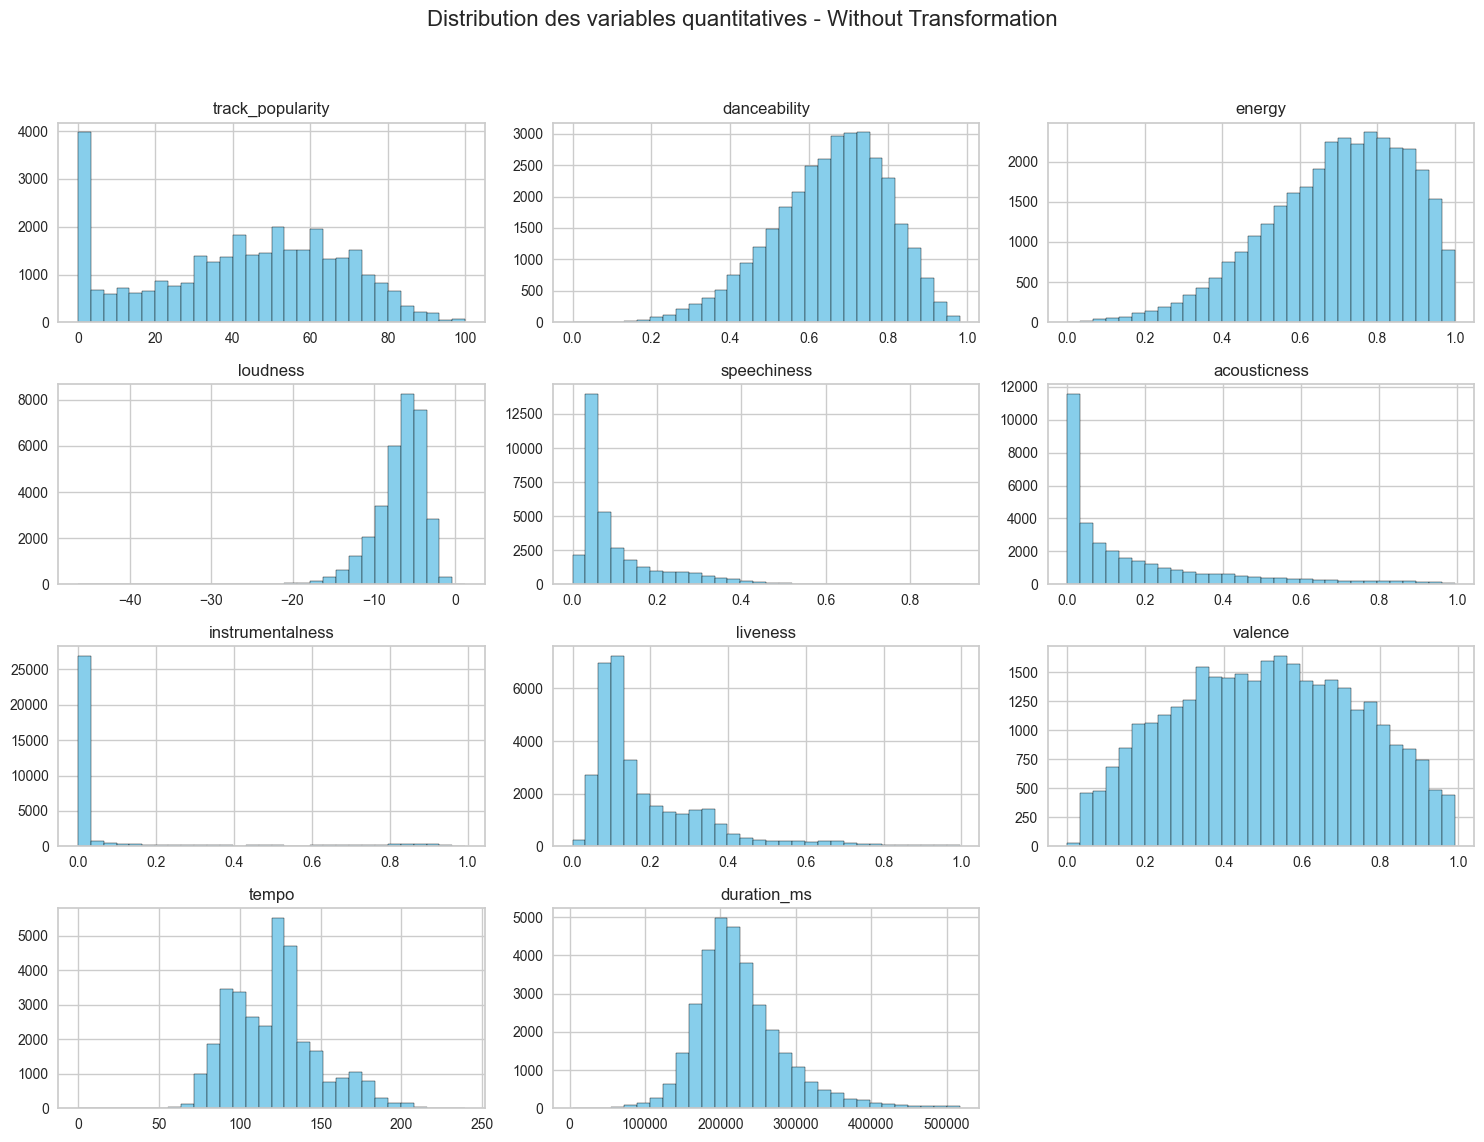

Skewness of quantitative variables:
track_popularity: -0.23
danceability: -0.50
energy: -0.64
loudness: -1.36
speechiness: 1.97
acousticness: 1.59
instrumentalness: 2.76
liveness: 2.08
valence: -0.01
tempo: 0.53
duration_ms: 1.15
Variables avec une asymétrie élevée: ['loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness']


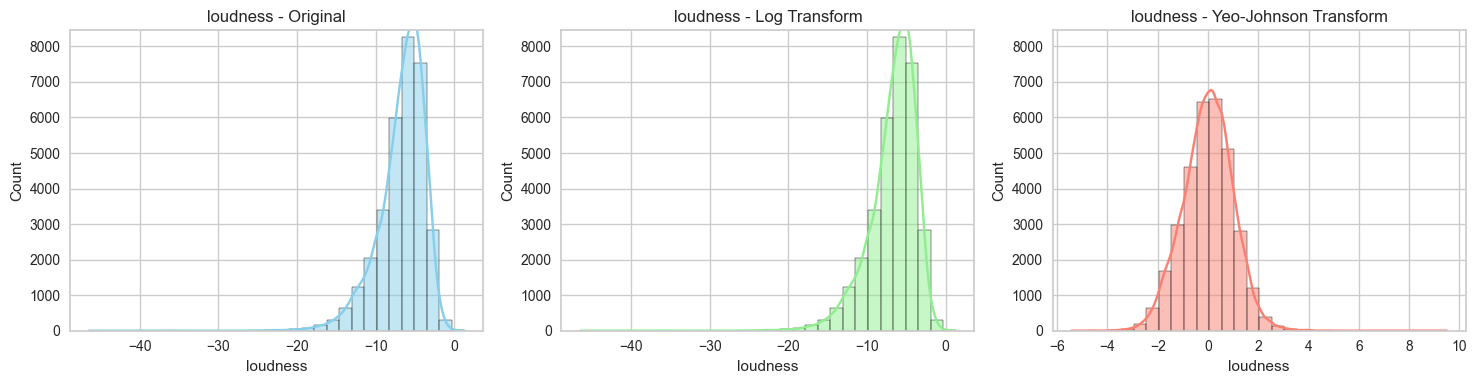

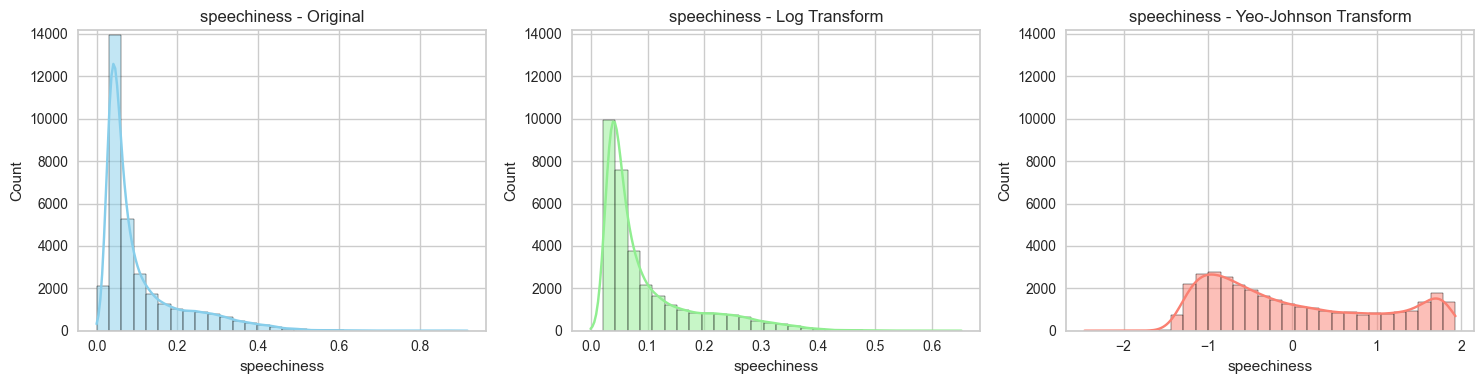

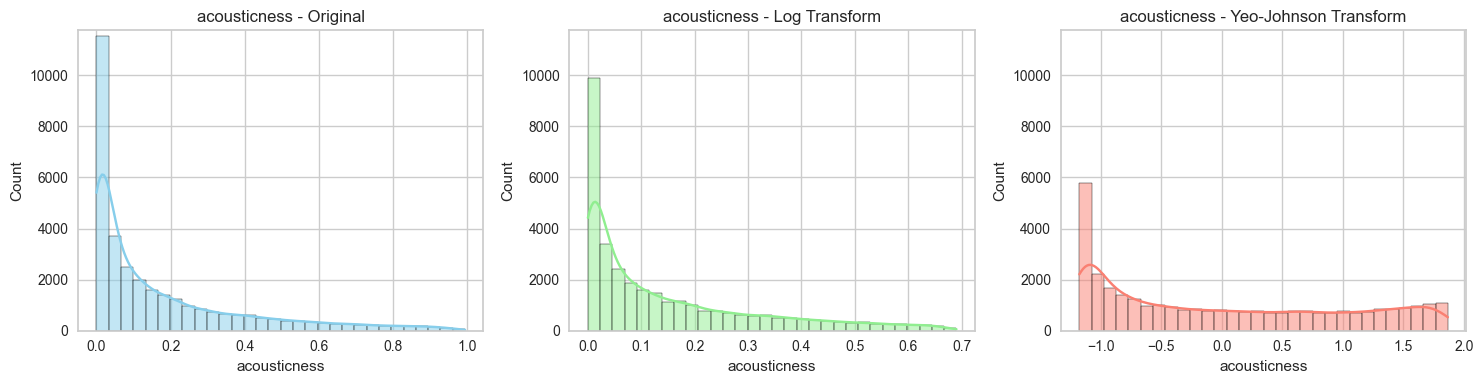

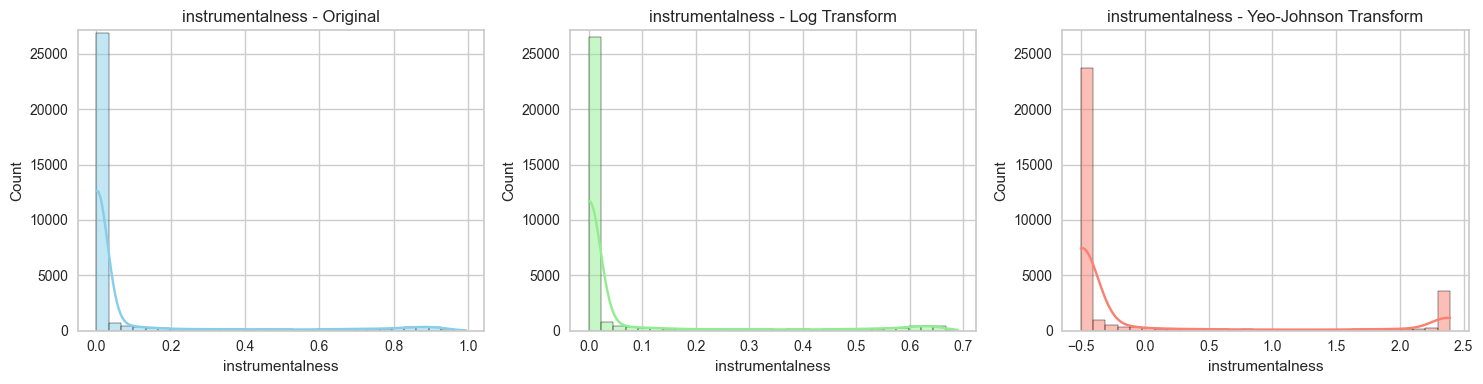

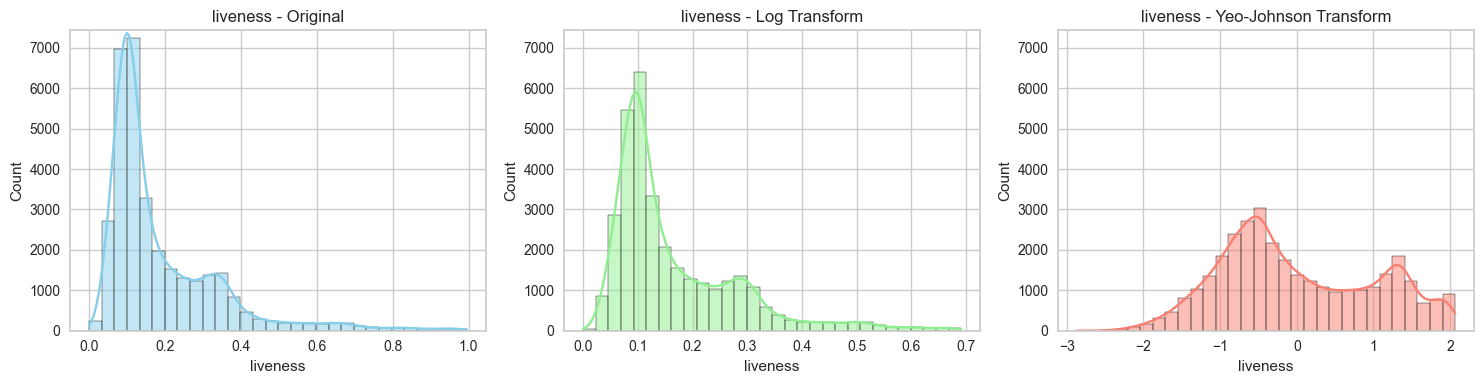

Skewness comparison after transformations:
                  Original       Log  Yeo-Johnson
loudness         -1.363997 -1.363997    -0.003220
speechiness       1.967659  1.719290     0.509308
acousticness      1.594553  1.296568     0.403712
instrumentalness  2.759187  2.607333     1.748006
liveness          2.076842  1.664519     0.304086


In [7]:
from sklearn.preprocessing import PowerTransformer

data_to_transform = data_complete.copy()

# histogrammes avant transformation
data_to_transform[quant_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Distribution des variables quantitatives - Without Transformation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# calcul de la skewness/Asymétrie
# --> on cherche ici à identifier les variables quantitatives qui ont une forte asymétrie (skewness) pour les transformer ensuite et les rendre plus gaussiennes
print('Skewness of quantitative variables:')
var_to_gauss = []
for col in quant_cols:
    skewness = data_to_transform[col].skew()
    print(f"{col}: {skewness:.2f}")
    if abs(skewness) > 1.3:
        var_to_gauss.append(col)

print(f"Variables avec une asymétrie élevée: {var_to_gauss}")

# LOG
data_gauss_log = data_to_transform.copy()
for col in ["speechiness", "acousticness", "instrumentalness", "liveness"]:
    if col in data_gauss_log.columns:
        data_gauss_log[col] = np.log1p(data_gauss_log[col])

# YEO-JOHNSON : accepte aussi 0 et négatifs
data_gauss_yeo = data_to_transform.copy()
if var_to_gauss:
    pt_yeo = PowerTransformer(method="yeo-johnson")
    data_gauss_yeo[var_to_gauss] = pt_yeo.fit_transform(data_gauss_yeo[var_to_gauss])

# visualisation
for col in var_to_gauss:
    
    # Compute common y-axis limit
    counts_original, _ = np.histogram(data_to_transform[col].dropna(), bins=30)
    counts_log, _ = np.histogram(data_gauss_log[col].dropna(), bins=30)
    counts_yeo, _ = np.histogram(data_gauss_yeo[col].dropna(), bins=30)

    max_count = max(
        counts_original.max(),
        counts_log.max(),
        counts_yeo.max()
    ) + 200  # add some margin

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    sns.histplot(
        data_to_transform[col],
        bins=30,
        kde=True,
        color='skyblue',
        edgecolor='black',
        ax=axes[0]
    )
    axes[0].set_title(f"{col} - Original")
    axes[0].set_ylim(0, max_count)

    sns.histplot(
        data_gauss_log[col],
        bins=30,
        kde=True,
        color='lightgreen',
        edgecolor='black',
        ax=axes[1]
    )
    axes[1].set_title(f"{col} - Log Transform")
    axes[1].set_ylim(0, max_count)


    sns.histplot(
        data_gauss_yeo[col],
        bins=30,
        kde=True,
        color='salmon',
        edgecolor='black',
        ax=axes[2]
    )
    axes[2].set_title(f"{col} - Yeo-Johnson Transform")
    axes[2].set_ylim(0, max_count)

    plt.tight_layout()
    plt.show()

# tableau comparatif
skewness_comparison = pd.DataFrame({
    "Original": data_to_transform[var_to_gauss].skew(),
    "Log": data_gauss_log[var_to_gauss].skew(),
    "Yeo-Johnson": data_gauss_yeo[var_to_gauss].skew()
})


print("Skewness comparison after transformations:")
print(skewness_comparison)


Nous observons une amélioration significative de la symétrie de nos variables quantitatives étudiées après transformation, notamment avec la transformation de Yeo-Johnson. Nous allons donc conserver les valeurs de ces variables transformées dans une nouvelle base de données appelée `data_gauss`, en renommant les colonnes concernées. 

In [8]:
data_gauss = data_gauss_yeo.copy()

# Create rename dictionary only for transformed variables
rename_dict = {col: col + "_yeo" for col in var_to_gauss}

# Rename columns
data_gauss = data_gauss.rename(columns=rename_dict)

quant_cols_gauss = [col + "_yeo" for col in var_to_gauss if col in var_to_gauss]
quant_cols_gauss += [col for col in quant_cols if col not in var_to_gauss]

print(f"Quantitative columns after transformation: {quant_cols_gauss}")
print(f"Variables: {data_gauss.columns.tolist()}")

Quantitative columns after transformation: ['loudness_yeo', 'speechiness_yeo', 'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'track_popularity', 'danceability', 'energy', 'valence', 'tempo', 'duration_ms']
Variables: ['track_name', 'track_artist', 'track_popularity', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness_yeo', 'mode', 'speechiness_yeo', 'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'valence', 'tempo', 'duration_ms']


##### Détection d'outliers

Dans cette partie, nous cherchons à détecter et supprimer les outliers qui pourraient nuire à la justesse de nos résultants.

In [9]:
# Outlier detection using IQR method with different k values

# Observe quantity of outliers for every variable
k=1.5
Q1 = data_gauss[quant_cols_gauss].quantile(0.25)
Q3 = data_gauss[quant_cols_gauss].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - k * IQR
upper = Q3 + k * IQR

removed = (
    (data_gauss[quant_cols_gauss] < lower) |
    (data_gauss[quant_cols_gauss] > upper)
).mean()

print(f"\nk = {k}")
print((removed * 100).round(2).astype(str) + " %")

# Variables with more than 5% outliers
high_outliers = removed[removed > 0.03]

print("\nVariables with > 3% outliers:")
if len(high_outliers) == 0:
    print("None")
else:
    print((high_outliers * 100).round(2).astype(str) + " %")



# Different values of k :
print("\nTotal number of removed rows for different values of k")
var_to_remove_outliers = quant_cols_gauss.copy()
var_to_remove_outliers.remove("instrumentalness_yeo")
var_to_remove_outliers.remove("duration_ms")

for k in [1, 1.5, 1.7, 1.8, 2, 2.3, 2.5]:
    Q1 = data_gauss[var_to_remove_outliers].quantile(0.25)
    Q3 = data_gauss[var_to_remove_outliers].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - k * IQR
    upper = Q3 + k * IQR

    mask = (
        (data_gauss[var_to_remove_outliers] >= lower) &
        (data_gauss[var_to_remove_outliers] <= upper)
    ).all(axis=1)

    removed_rows = 1 - mask.mean()

    print(f"k={k}: {removed_rows:.2%} rows removed")




k = 1.5
loudness_yeo             1.07 %
speechiness_yeo           0.0 %
acousticness_yeo          0.0 %
instrumentalness_yeo    21.27 %
liveness_yeo              0.0 %
track_popularity          0.0 %
danceability             0.89 %
energy                   0.84 %
valence                   0.0 %
tempo                    1.74 %
duration_ms              4.23 %
dtype: str

Variables with > 3% outliers:
instrumentalness_yeo    21.27 %
duration_ms              4.23 %
dtype: str

Total number of removed rows for different values of k
k=1: 16.52% rows removed
k=1.5: 4.07% rows removed
k=1.7: 2.31% rows removed
k=1.8: 1.59% rows removed
k=2: 0.73% rows removed
k=2.3: 0.16% rows removed
k=2.5: 0.11% rows removed


Les outliers ont été identifiés à l’aide de la méthode de l’IQR, qui consiste à identifier les valeurs aberrantes en utilisant l’intervalle interquartile (Q3 − Q1) et en définissant des bornes au-delà desquelles les observations sont considérées comme extrêmes. 

On observe que variable `instrumentalness_yeo`, ainsi que la variable `duration_ms` présentent naturellement une distribution très asymétrique, ce qui explique le nombre plus élevé de valeurs extrêmes observées. Nous n'allons pas appliquer ce filtre pour ces deux variables, car on perdrait trop d'informations.

Le paramètre k contrôle la sévérité de la détection. Après comparaison de plusieurs valeurs de k, on choisi la valeur k = 1.7, car elle permet de limiter la suppression des données (environ 2 % des observations).


=== OUTLIER REMOVAL SUMMARY ===

Before outlier removal: 32828 rows
After outlier removal: 32070 rows
Rows removed: 758 (2.31%)


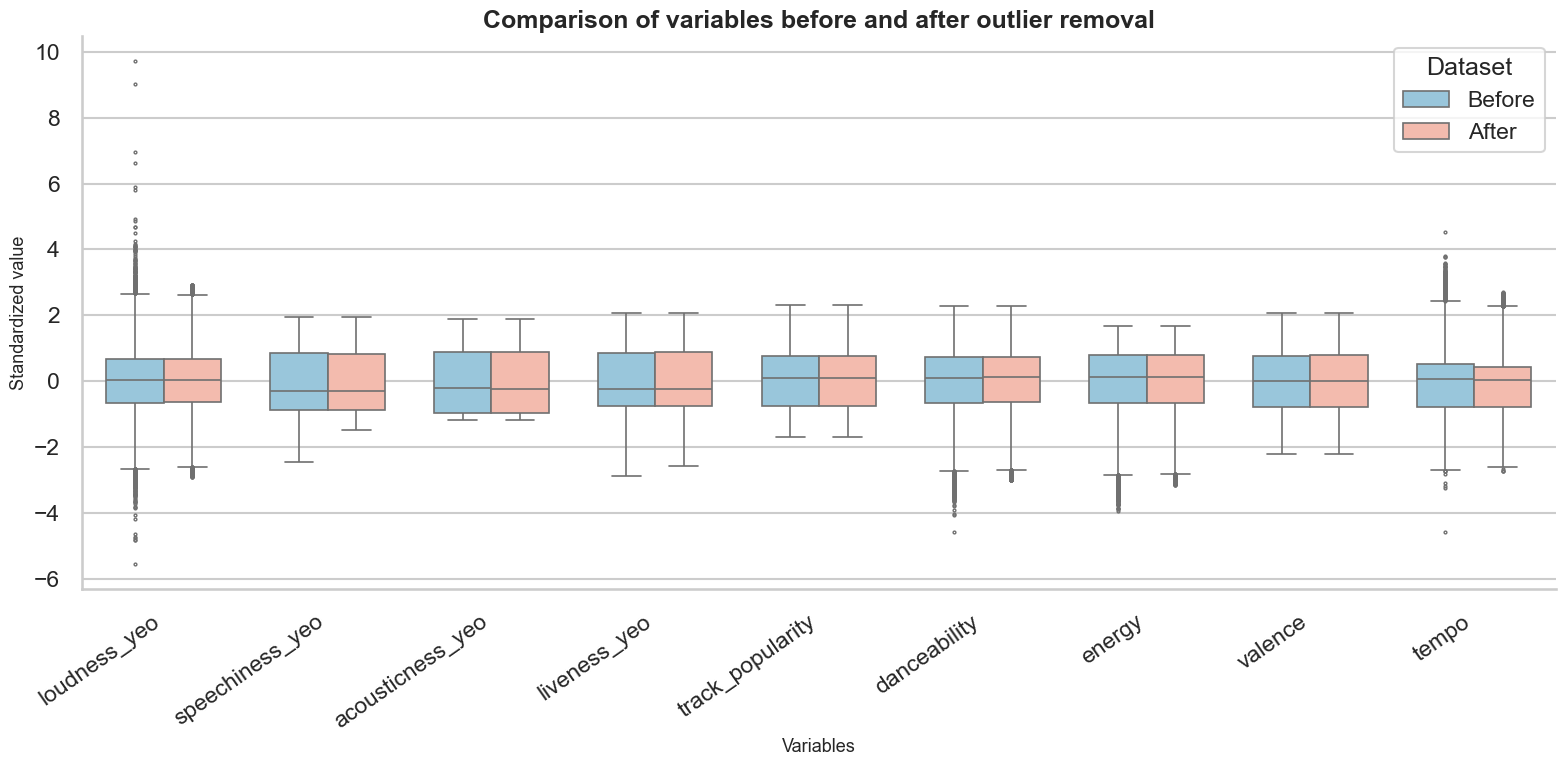

In [10]:
## BOXPLOTS


# Removing outliers with the IQR method
k = 1.7

Q1 = data_gauss[var_to_remove_outliers].quantile(0.25)
Q3 = data_gauss[var_to_remove_outliers].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - k * IQR
upper = Q3 + k * IQR

mask = (
    (data_gauss[var_to_remove_outliers] >= lower) &
    (data_gauss[var_to_remove_outliers] <= upper)
).all(axis=1)

data_without_outliers = data_gauss[mask]

removed_pct = 1 - mask.mean()


# Print summary statistics before and after outlier removal
print("\n=== OUTLIER REMOVAL SUMMARY ===")
print(f"\nBefore outlier removal: {len(data_gauss)} rows")
print(f"After outlier removal: {len(data_without_outliers)} rows")
print(f"Rows removed: {len(data_gauss) - len(data_without_outliers)} ({(len(data_gauss) - len(data_without_outliers))/len(data_gauss)*100:.2f}%)")



# COMPARISON PLOT

# Long format: before / after
df_before = data_gauss[var_to_remove_outliers].copy()
df_before["dataset"] = "Before"

df_after = data_without_outliers[var_to_remove_outliers].copy()
df_after["dataset"] = "After"

df_comb = pd.concat([df_before, df_after], ignore_index=True)

# standardize for visualization only
features = var_to_remove_outliers
scaler = StandardScaler()
df_comb[features] = scaler.fit_transform(df_comb[features])

# reshape
df_comb = df_comb.melt(
    id_vars="dataset",
    var_name="feature",
    value_name="value"
)

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(16, 8))

ax = sns.boxplot(
    data=df_comb,
    x="feature",
    y="value",
    hue="dataset",
    palette={"Before": "#8ecae6", "After": "#ffb4a2"},
    width=0.7,
    linewidth=1.2,
    fliersize=2
)

ax.set_title("Comparison of variables before and after outlier removal", fontsize=18, weight="bold")
ax.set_xlabel("Variables", fontsize=13)
ax.set_ylabel("Standardized value", fontsize=13)

plt.xticks(rotation=35, ha="right")
plt.legend(title="Dataset", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

Les boxplots montrent une diminution du nombre de valeurs extrêmes après le traitement des outliers, ainsi qu’une légère réduction de la dispersion pour certaines variables comme `tempo`ou `danceability`. Néanmoins, les médianes restent globalement stables, ce qui indique que la suppression des observations aberrantes a permis d’améliorer la robustesse des données sans altérer de manière significative les caractéristiques principales des distributions.


##### Normalisation

In [11]:
data_centered = data_without_outliers.copy()
data_centered[quant_cols_gauss] = StandardScaler().fit_transform(data_centered[quant_cols_gauss])

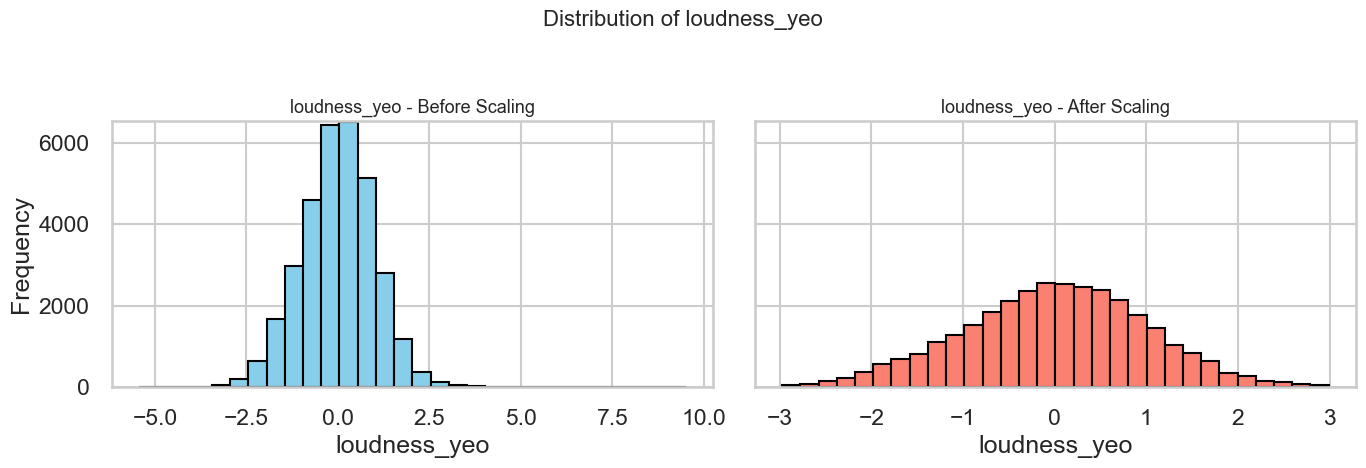

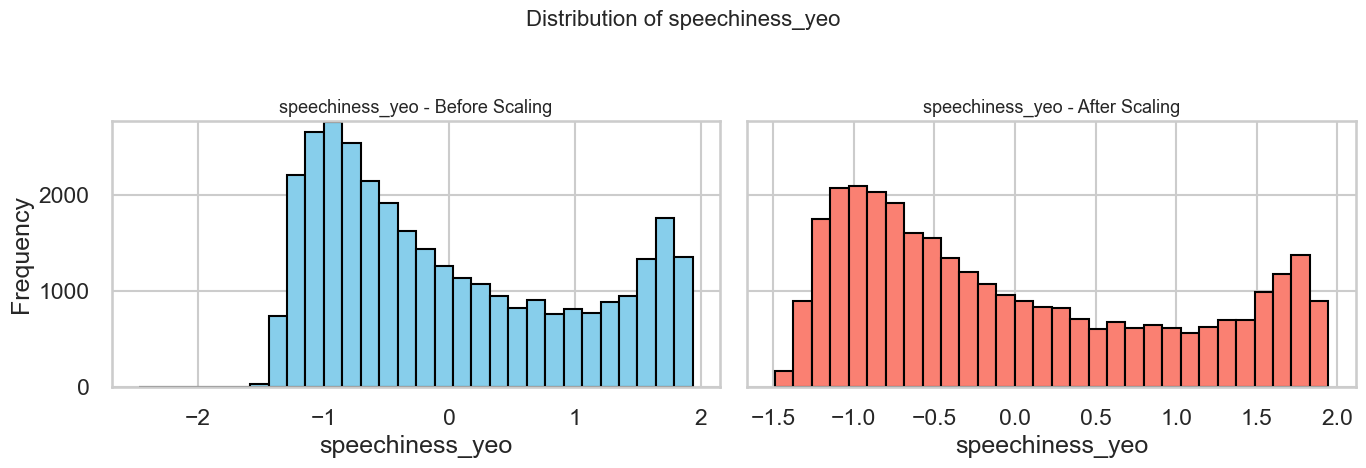

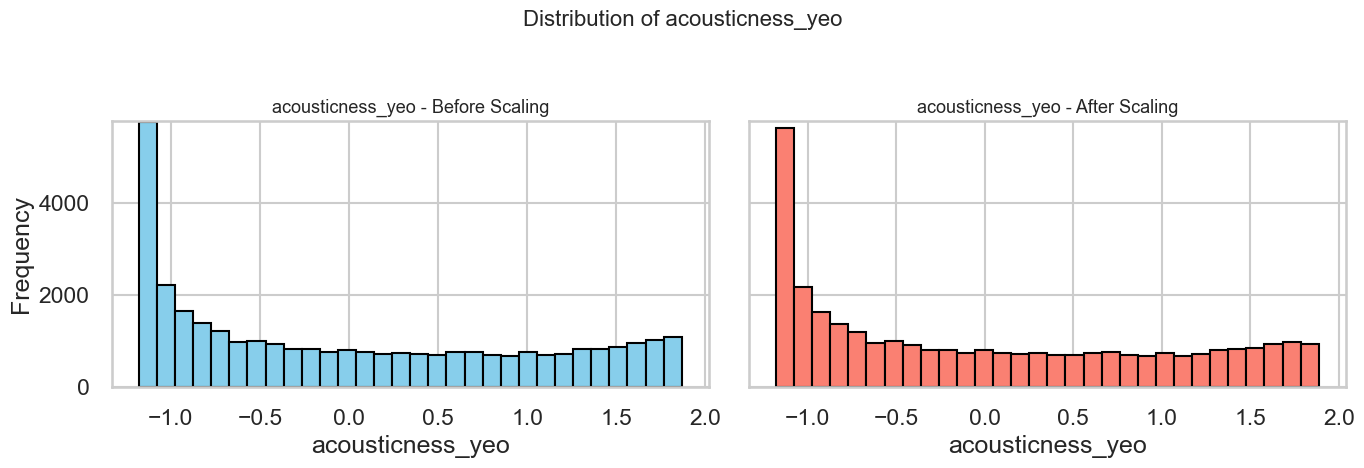

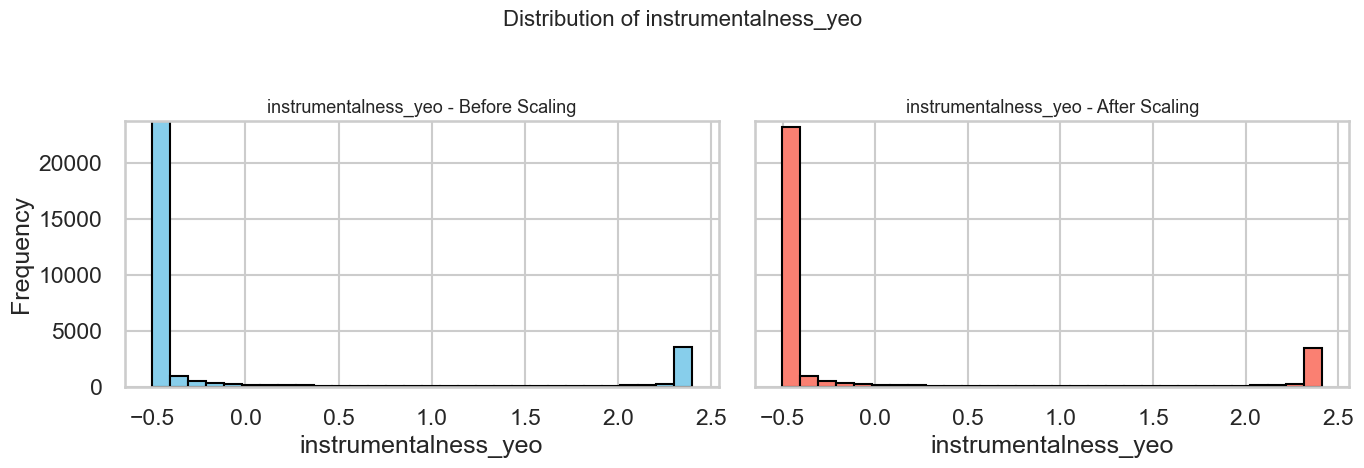

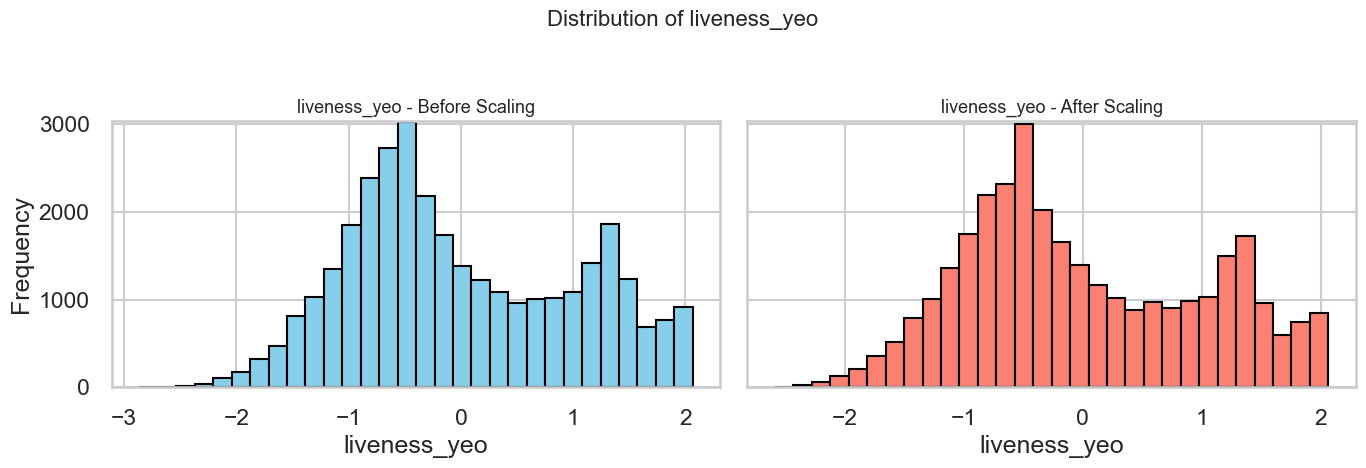

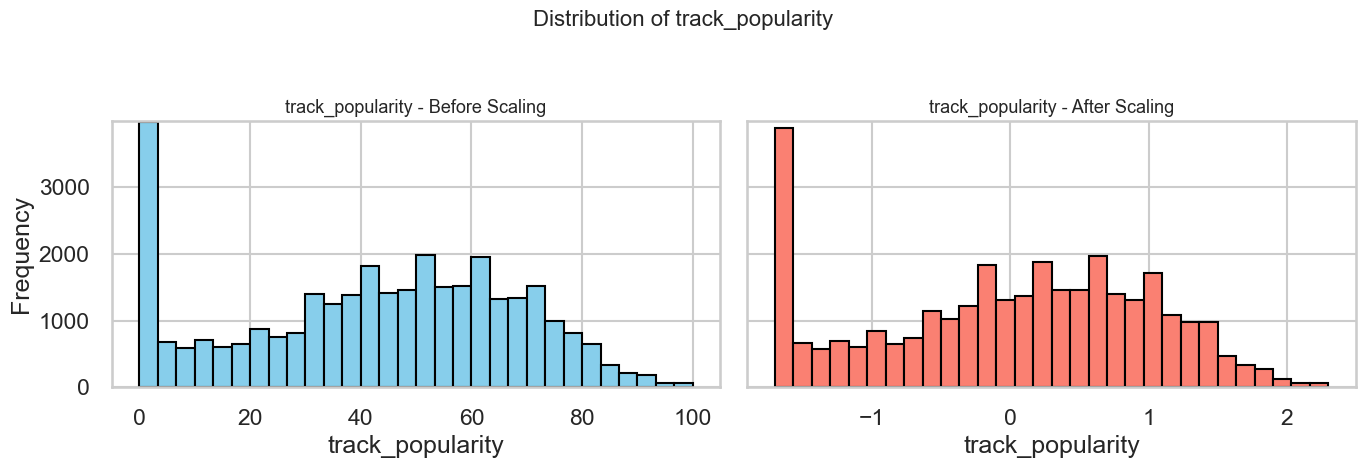

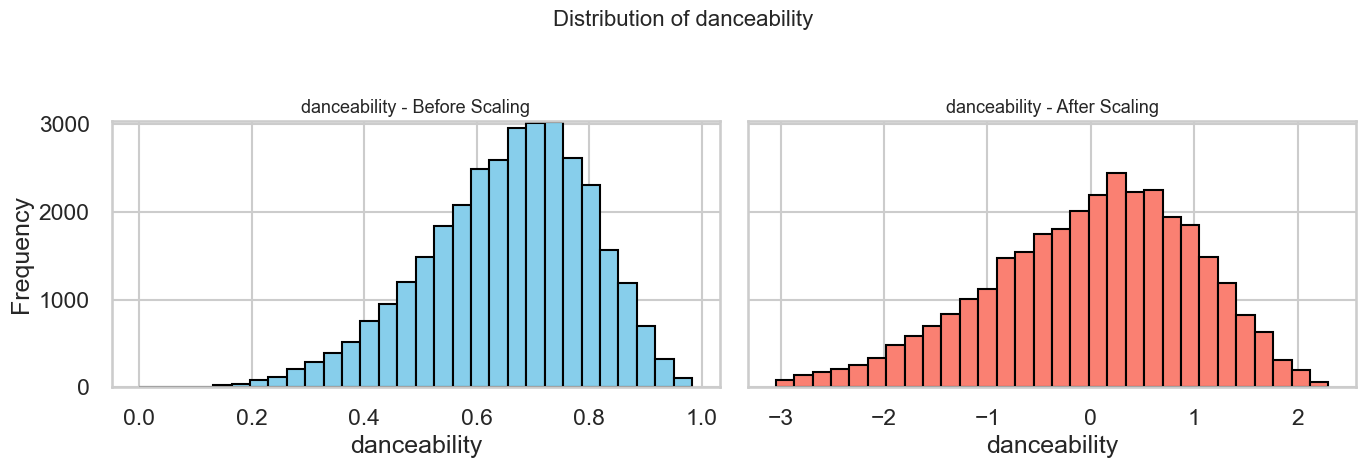

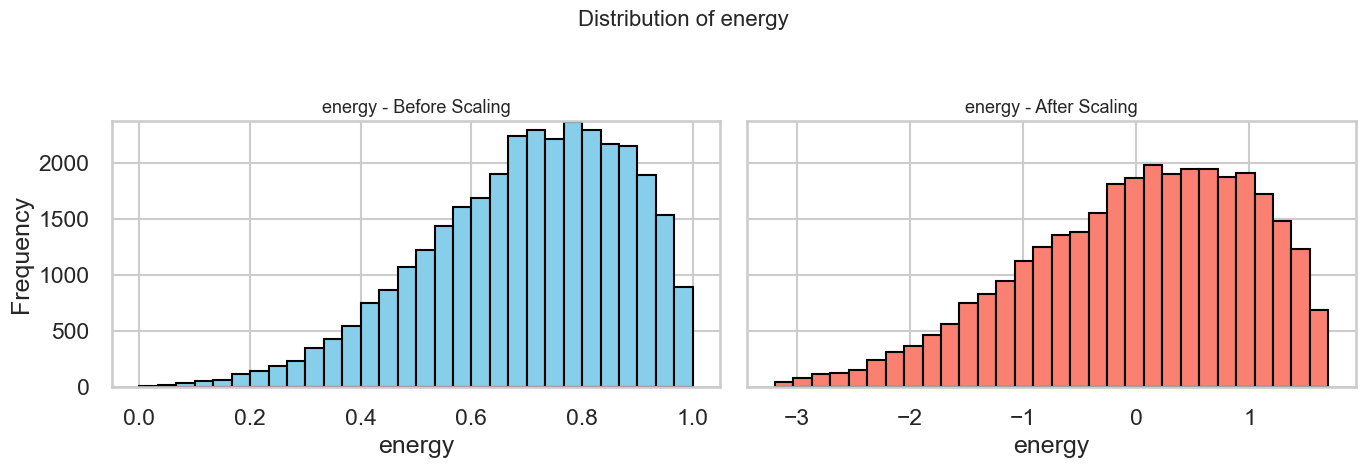

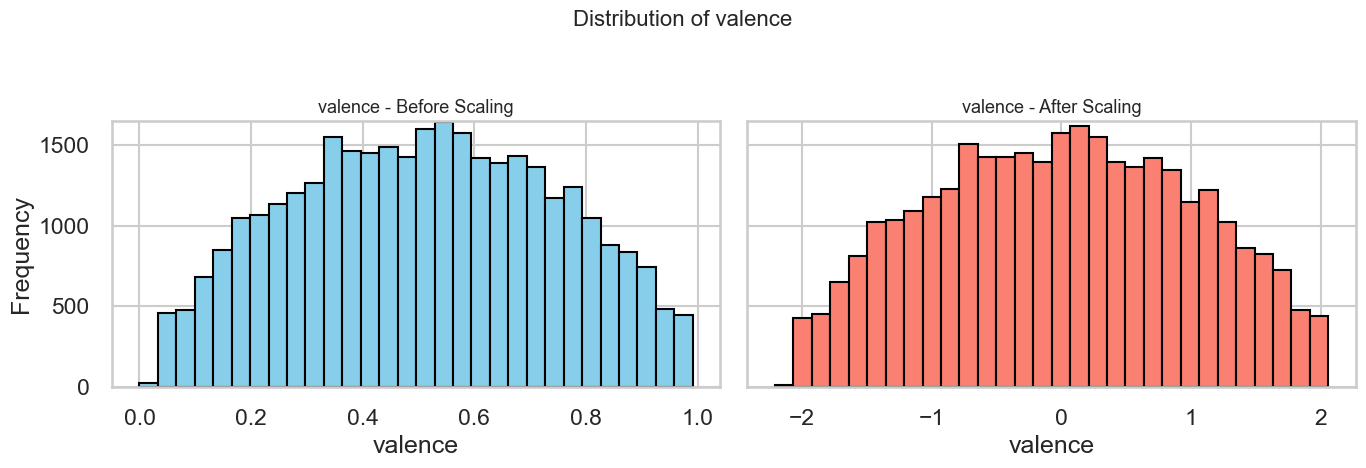

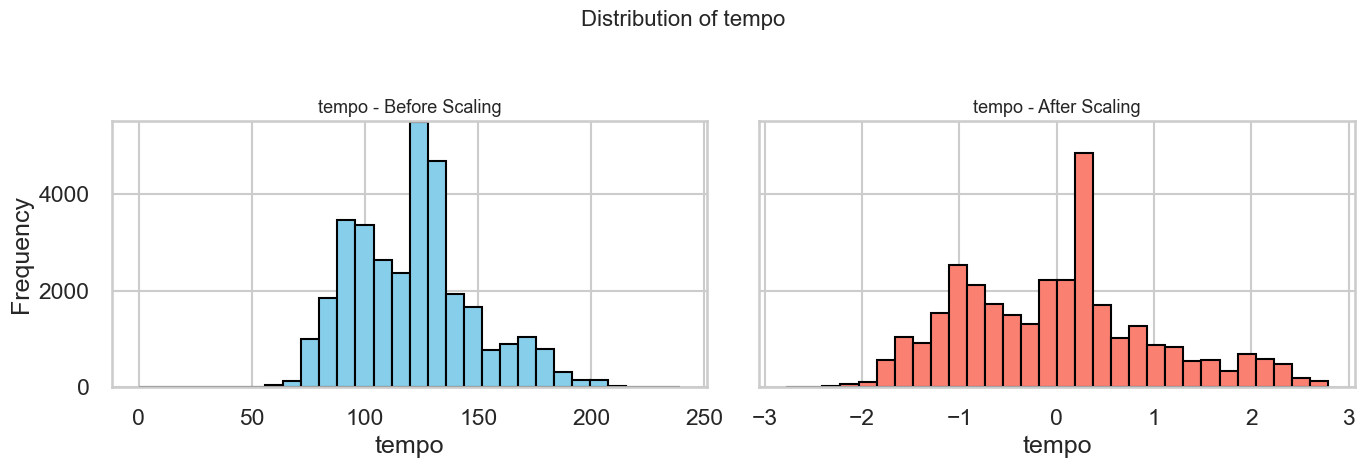

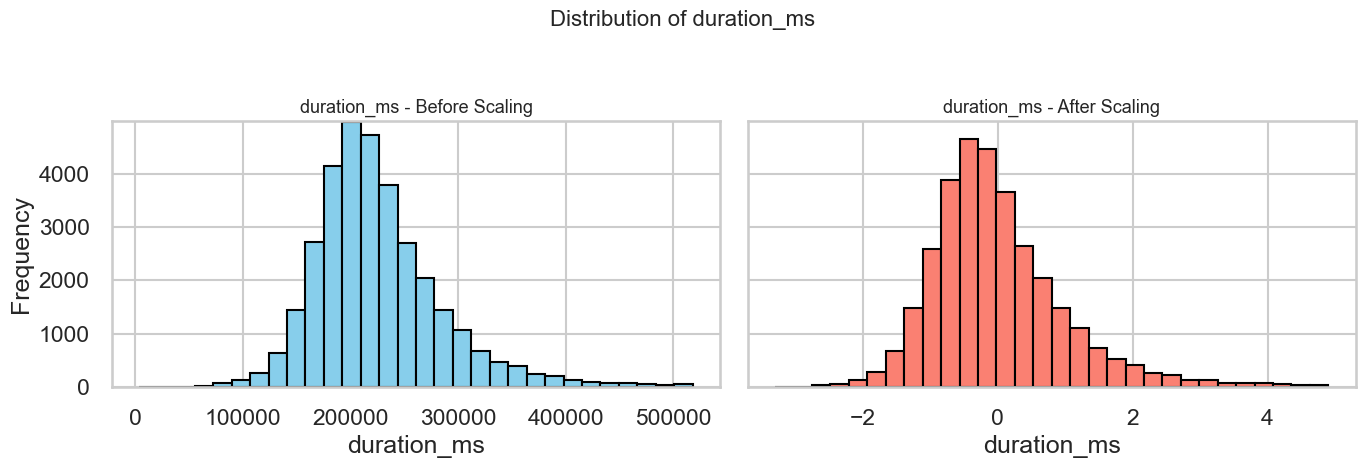

In [12]:
for col in quant_cols_gauss:
    
    # Compute common y-axis limit
    counts_gauss, _ = np.histogram(data_gauss[col].dropna(), bins=30)
    counts_centered, _ = np.histogram(data_centered[col].dropna(), bins=30)

    max_count = max(counts_gauss.max(), counts_centered.max()) + 5  # small margin

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Before scaling
    axes[0].hist(
        data_gauss[col].dropna(),
        bins=30,
        color='skyblue',
        edgecolor='black'
    )
    axes[0].set_title(f"{col} - Before Scaling", fontsize=13)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[0].set_ylim(0, max_count)

    # After scaling
    axes[1].hist(
        data_centered[col].dropna(),
        bins=30,
        color='salmon',
        edgecolor='black'
    )
    axes[1].set_title(f"{col} - After Scaling", fontsize=13)
    axes[1].set_xlabel(col)
    axes[1].set_ylim(0, max_count)

    plt.suptitle(f"Distribution of {col}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

##### Données prétraitées

Nous pouvons donc définir le dataframe `data` comme notre jeu de données propre après le prétraitement effectué ci-dessus, que nous utiliserons tout au long de notre étude. Le jeu de données final contient N observations et P variables quantitatives centrées et réduites. L’analyse descriptive montre que les variables sont désormais standardisées, avec une moyenne proche de 0 et une dispersion comparable entre les différentes caractéristiques.

Voici les différentes notations introduites : 

Bases de données (dataframes) :
* data_initial :  données importées brutes
* data_complete : data_initial mais sans les colonnes inutiles et les colonnes significativement vides
* data_gauss : data_complete mais avec les transformations pour gaussianiser les variables les plus asymétriques
* data_without_outliers : data_gauss mais en enlevant des données aberrantes (2% des données totales)
* data_centered : data_without_outliers mais centre-réduit
* data : dataframe avec toutes les modifications ci-dessus

Variables (listes) :
* qual_cols : liste des variables qualitatives
* quant_cols : liste des variables quantitatives non transformées
* quant_cols_gauss : liste des variables quantitatives après transformation sur les variables les plus asymétriques
* var_to_gauss : liste des variables quantitatives transformées



In [13]:
# Copie du jeu de données centré
data = data_centered.copy()

print("=== Aperçu du jeu de données ===")
display(data.head())

print("\n=== Dimensions du jeu de données ===")
print(f"Nombre de lignes : {data.shape[0]}")
print(f"Nombre de variables : {data.shape[1]}")

print("\n=== Types des variables ===")
display(data.dtypes)

print("\n=== Valeurs manquantes ===")
display(data.isnull().sum())

print("\n=== Statistiques descriptives ===")
display(data.describe())

=== Aperçu du jeu de données ===


,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness_yeo,mode,speechiness_yeo,acousticness_yeo,instrumentalness_yeo,liveness_yeo,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,0.938467,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,pop,dance pop,0.632935,1.223901,6,1.875621,1,-0.380608,-0.015490,-0.500338,-1.240353,0.023140,0.076864,-0.526017
1,Memories - Dillon Francis Remix,Maroon 5,0.978440,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.477207,0.648108,11,0.532599,1,-0.970760,-0.290401,-0.336678,1.381027,0.776228,-0.782359,-1.066234
2,All the Time - Don Diablo Remix,Zara Larsson,1.098359,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.116202,1.309415,1,1.344702,0,-0.020391,-0.221499,-0.499404,-0.480337,0.431959,0.153659,-0.830752
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,0.698628,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.420579,1.303714,7,1.141469,1,0.472041,-0.784073,-0.499960,0.555098,-1.013970,0.073749,-0.957145
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,1.058386,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,-0.060762,0.750724,1,0.673179,1,-1.015529,-0.212823,-0.500338,-0.906930,0.913936,0.152413,-0.621816



=== Dimensions du jeu de données ===
Nombre de lignes : 32070
Nombre de variables : 20

=== Types des variables ===


track_name                       str
track_artist                     str
track_popularity             float64
track_album_name                 str
track_album_release_date         str
playlist_name                    str
playlist_genre              category
playlist_subgenre           category
danceability                 float64
energy                       float64
key                         category
loudness_yeo                 float64
mode                        category
speechiness_yeo              float64
acousticness_yeo             float64
instrumentalness_yeo         float64
liveness_yeo                 float64
valence                      float64
tempo                        float64
duration_ms                  float64
dtype: object


=== Valeurs manquantes ===


track_name                  0
track_artist                0
track_popularity            0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness_yeo                0
mode                        0
speechiness_yeo             0
acousticness_yeo            0
instrumentalness_yeo        0
liveness_yeo                0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


=== Statistiques descriptives ===


,track_popularity,danceability,energy,loudness_yeo,speechiness_yeo,acousticness_yeo,instrumentalness_yeo,liveness_yeo,valence,tempo,duration_ms
count,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04,3.207000e+04
mean,1.417984e-17,-3.119564e-16,1.063488e-17,-1.417984e-17,4.608447e-17,-1.772480e-17,7.089918e-17,1.063488e-17,1.843379e-16,-3.615858e-16,7.089918e-18
std,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00,1.000016e+00
min,-1.699754e+00,-3.047907e+00,-3.194317e+00,-2.973018e+00,-1.487743e+00,-1.178956e+00,-5.003384e-01,-2.583303e+00,-2.205958e+00,-2.778310e+00,-3.302553e+00
25%,-7.404013e-01,-6.553596e-01,-6.745073e-01,-6.590589e-01,-8.559474e-01,-9.633294e-01,-5.003384e-01,-7.481111e-01,-7.729820e-01,-7.835666e-01,-6.394904e-01
50%,9.903269e-02,1.091230e-01,1.179215e-01,2.721263e-02,-2.836815e-01,-2.186024e-01,-4.997291e-01,-2.449897e-01,1.022971e-02,6.239738e-02,-1.670486e-01
75%,7.785745e-01,7.320348e-01,7.906309e-01,6.804577e-01,8.354770e-01,8.908785e-01,-3.238973e-01,8.762251e-01,7.848347e-01,4.669402e-01,4.648843e-01
max,2.297550e+00,2.296393e+00,1.697078e+00,2.990774e+00,1.944208e+00,1.886324e+00,2.414456e+00,2.061093e+00,2.058630e+00,2.786784e+00,4.901620e+00


### 2. Analyse unidimensionnelle des variables

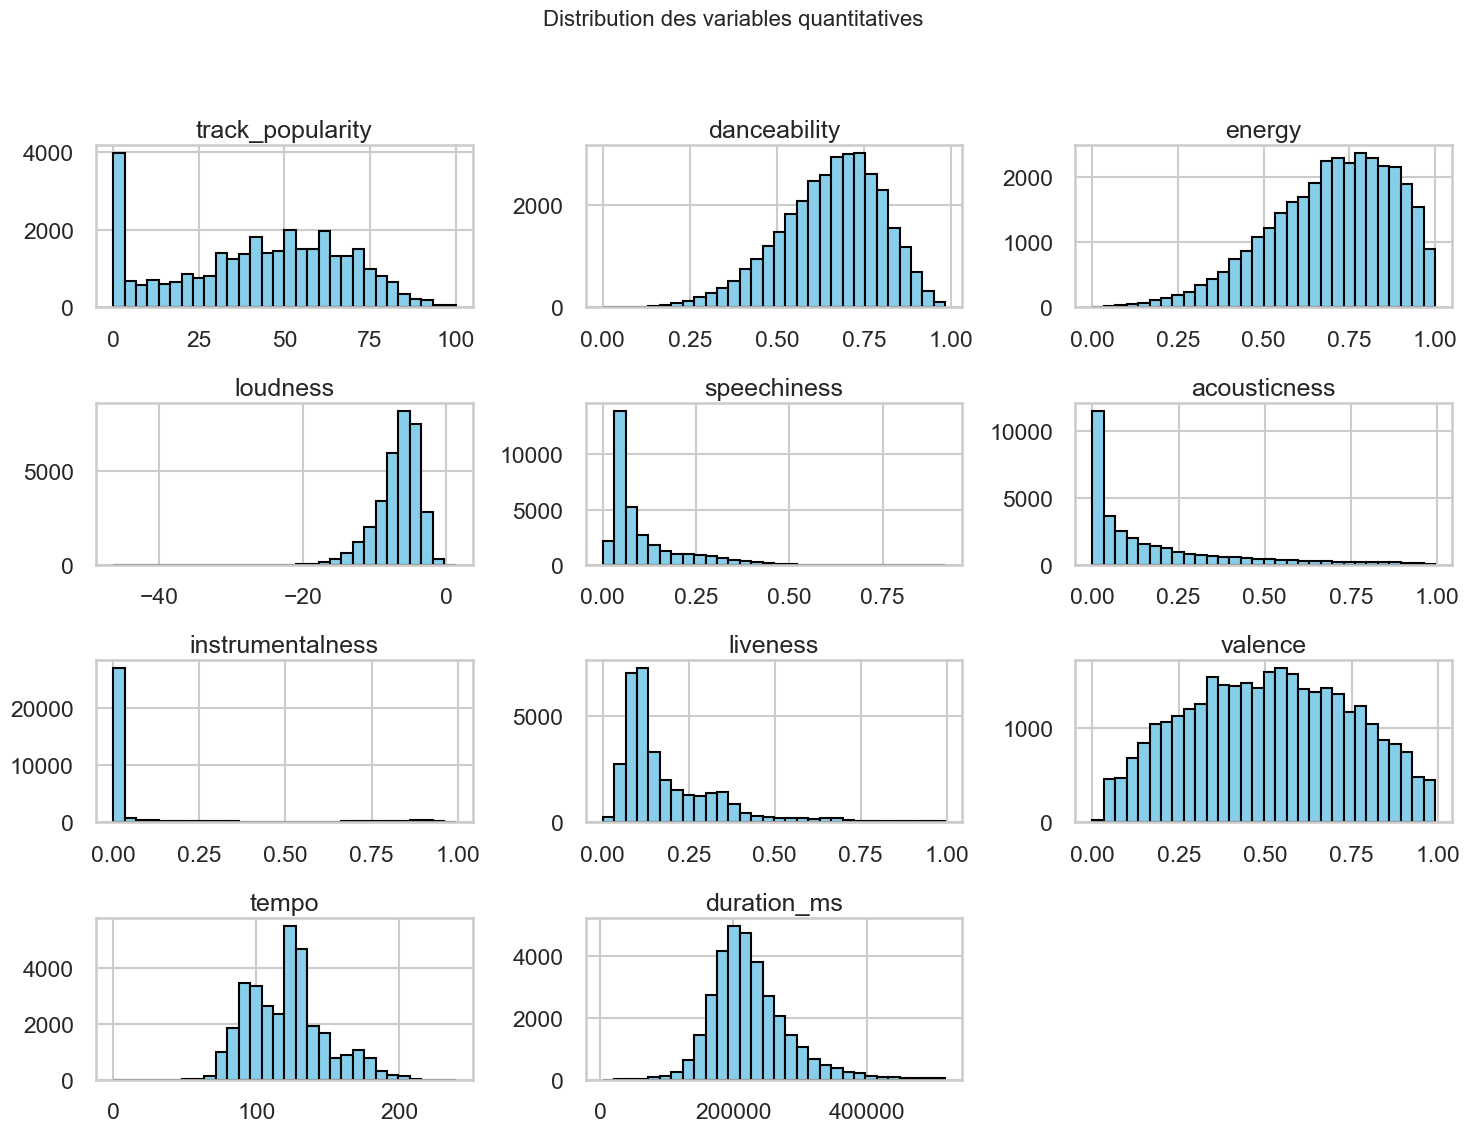

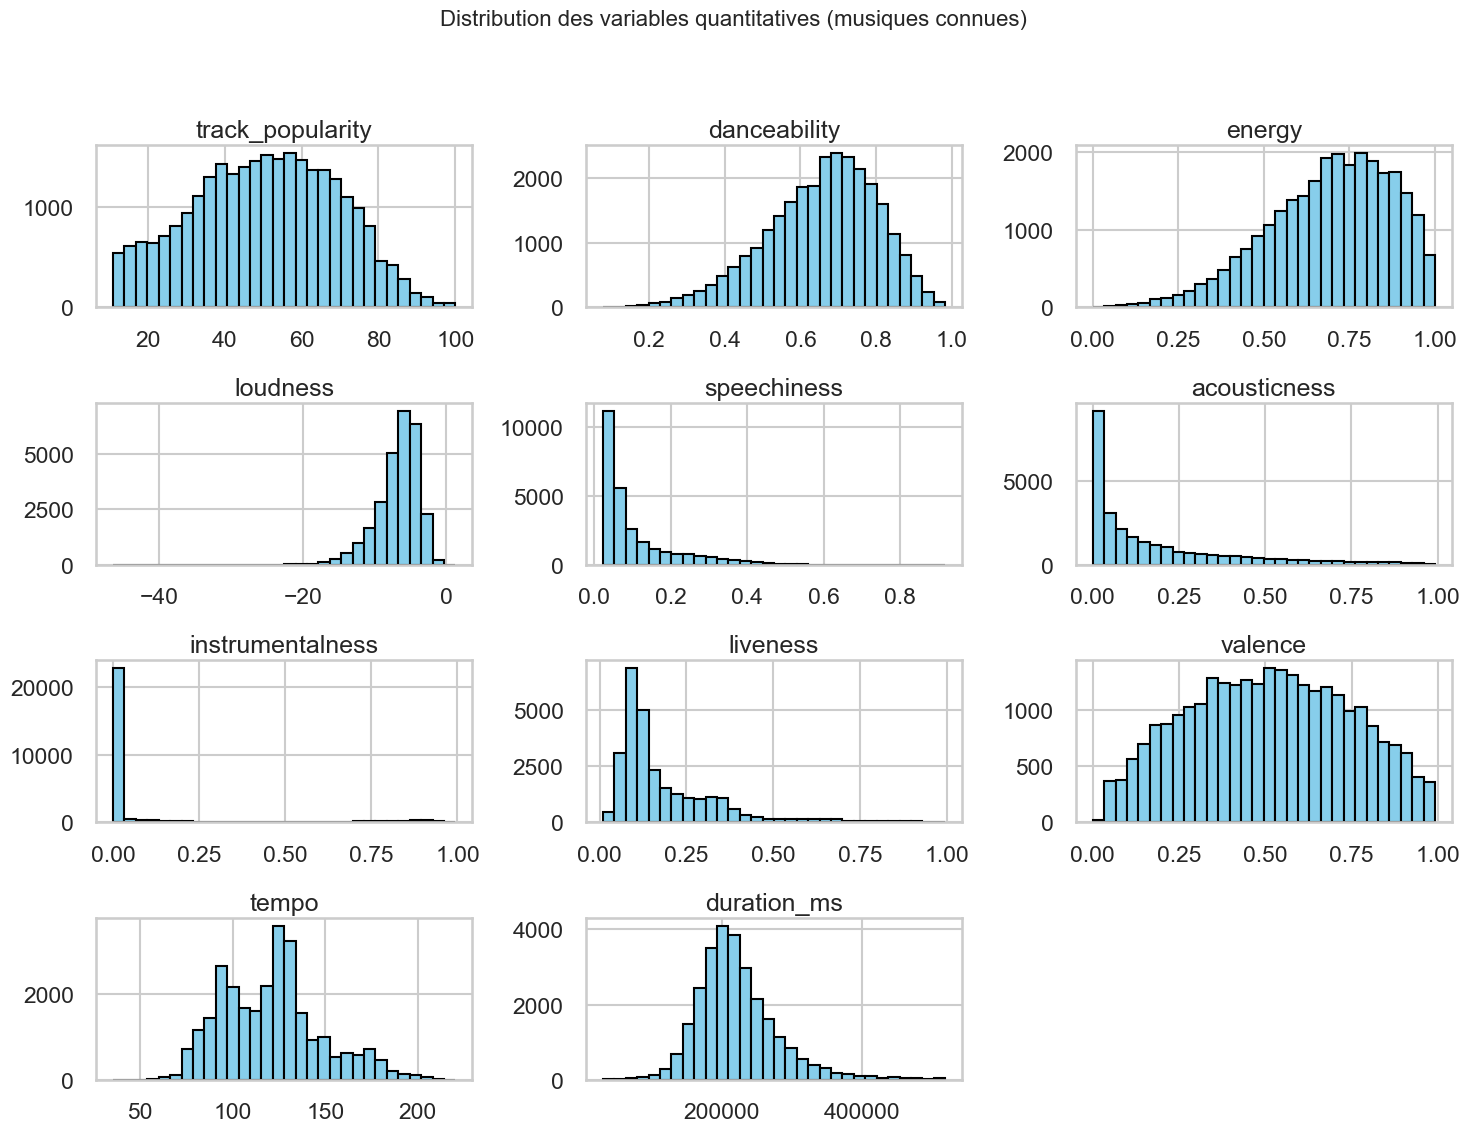

Part de morceaux peu connus : 0.16
Part de morceaux peu instrumental : 0.85
Part de morceaux peu acoustique : 0.54


In [14]:
data_connu = data_complete[data_complete["track_popularity"]>10]


# 2. Tracer les histogrammes
data_complete[quant_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')

# 3. Ajuster l'affichage pour éviter le chevauchement
plt.suptitle("Distribution des variables quantitatives", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Tracer les histogrammes
data_connu[quant_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')

# 3. Ajuster l'affichage pour éviter le chevauchement
plt.suptitle("Distribution des variables quantitatives (musiques connues)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

part_pas_connus=len(data_complete[data_complete["track_popularity"]<10])/len(data_complete)
print(f"Part de morceaux peu connus : {round(part_pas_connus,2)}")
part_peu_instrumental=len(data_complete[data_complete["instrumentalness"]<0.1])/len(data_complete)
print(f"Part de morceaux peu instrumental : {round(part_peu_instrumental,2)}")
part_peu_acoustic=len(data_complete[data_complete["acousticness"]<0.1])/len(data_complete)
print(f"Part de morceaux peu acoustique : {round(part_peu_acoustic,2)}")

#### a) Les distributions des variables quantitatives

Les distributions observées sont globalement variées, avec plusieurs variables asymétriques.

`track_popularity` est répartie sur \([0,100]\) avec davantage de morceaux faiblement populaires. Il y a notamment un grande concentration de morceaux qui sont peu connus

`danceability` et `energy` sont concentrées sur des valeurs élevées. Les morceaux sont donc globalement rythmés et dynamiques.

`loudness` est centré sur des valeurs fortes, cohérentes avec des productions modernes.

`speechiness`, `acousticness`, `instrumentalness` et `liveness` présentent une forte concentration proche de 0. La majorité des morceaux contiennent donc peu de parole, sont peu acoustiques, peu instrumentaux et rarement enregistrés avec une audiance.

`valence` est plus équilibrée, sans valeur atypiquement représentée.

`tempo` est principalement compris entre 100 et 130 BPM, qui est caractéristique des musiques pop ou rap.

`duration_ms` est centré autour de 200000 à 250000 ms, ce qui est cohérent : les musiques durent en moyenne entre 3 et 4 minutes.

#### Indicateurs calculés

- 16 % des morceaux sont très peu connus
- 85 % des morceaux sont très peu instrumentaux : la base est très majoritairement composée de morceaux chantés.
- 54 % des morceaux sont très peu acoustiques : La majorité des musiques utilise des transformations numériques/électroniques

#### Distributions identiques pour les musiques connues

Après retrait des morceaux très peu connus, les distributions restent presque identiques. Cependant, cette part de morceaux très peu connus (16%) n'est pas négligeable et est à considérer lors de nos interprétations et notre étude de la popularité.

La principale différence concerne `speechiness` : les valeurs extrêmement faibles deviennent moins présentes. Cela suggère qu’un morceau avec une composante vocale totalement absente est moins susceptible d’être populaire.


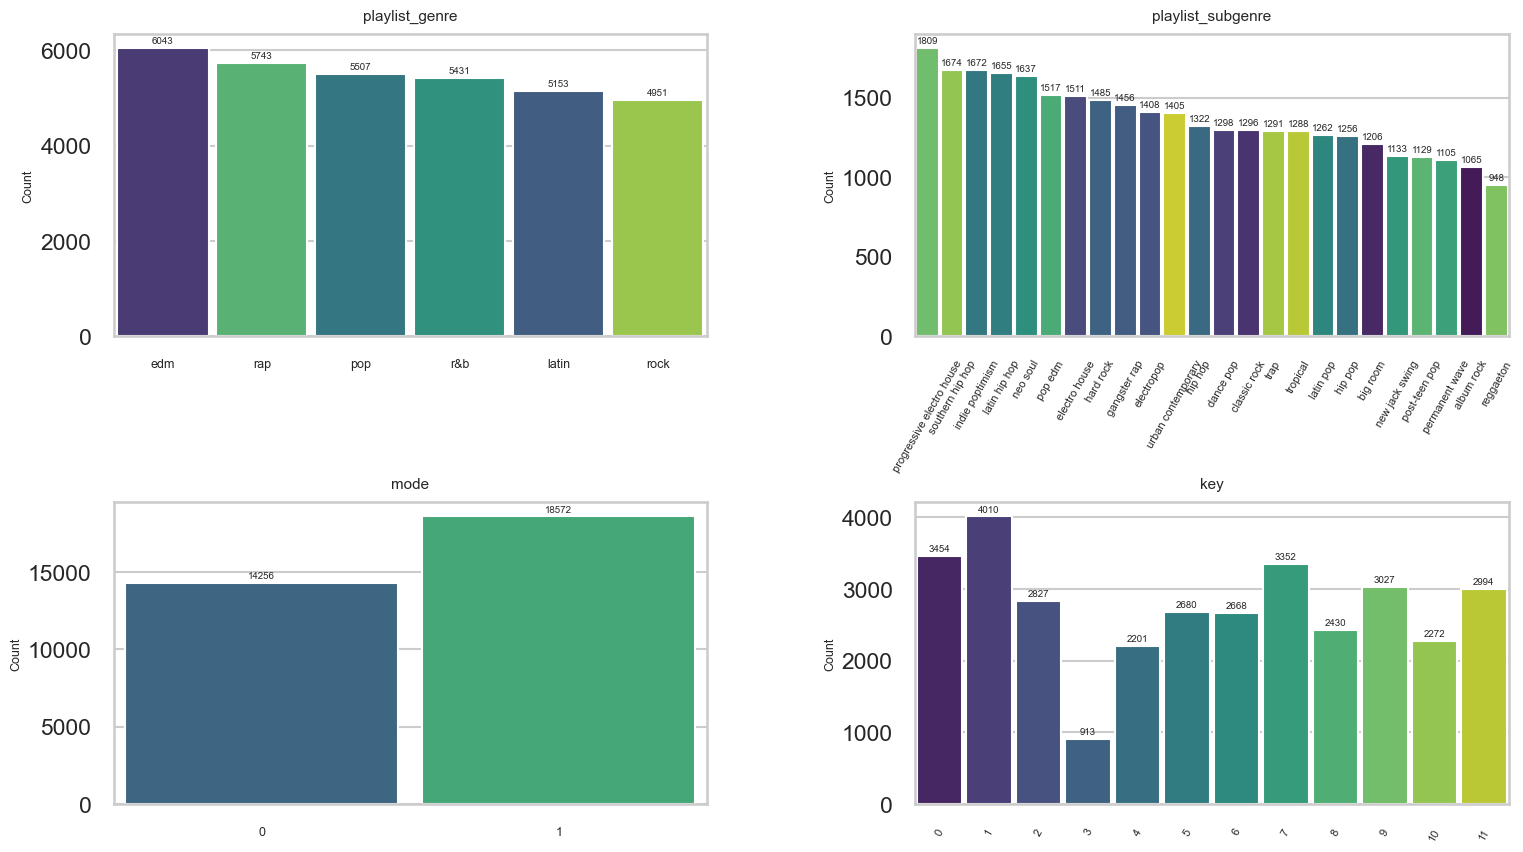

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))  # plus large
axes = axes.flatten()

for i, col in enumerate(qual_cols[:4]):
    ax = axes[i]

    if col in ["key", "mode"]:
        order = sorted(data_complete[col].dropna().unique())
    else:
        order = data_complete[col].value_counts().index.tolist()

    sns.countplot(
        data=data_complete,
        x=col,
        order=order,
        hue=col,
        dodge=False,
        palette="viridis",
        legend=False,
        ax=ax
    )

    # élargir visuellement les barres
    for bar in ax.patches:
        current_width = bar.get_width()
        new_width = current_width * 1.15
        diff = new_width - current_width

        bar.set_width(new_width)
        bar.set_x(bar.get_x() - diff / 2)

        h = bar.get_height()
        ax.annotate(
            f"{int(h)}",
            (bar.get_x() + bar.get_width()/2, h),
            ha="center",
            va="bottom",
            fontsize=7,
            xytext=(0, 2),
            textcoords="offset points"
        )

    ax.set_title(col, fontsize=11, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=9)

    # rotation + taille labels
    if len(order) > 8:
        ax.tick_params(axis="x", rotation=60, labelsize=8)
    else:
        ax.tick_params(axis="x", labelsize=9)

plt.subplots_adjust(hspace=0.55, wspace=0.35)
plt.show()

#### b) Analyse des variables qualitatives

La variable `playlist_genre` est globalement équilibrée entre les six genres principaux (EDM, Rap, Pop, R&B, Latin, Rock) ce qui confirme la création volontaire d'une base de donnée sans domination excessive d’un genre.

La variable `playlist_subgenre` est plus dispersée. Cela suggère que certains sous-genres sont plus utilisés dans les playlists Spotify, tandis que d’autres sont plus niche.

Les morceaux en mode majeur sont plus nombreux. Cela est cohérent avec la musique grand public, souvent construite sur des tonalités plus lumineuses ou positives.

La répartition de la variable `key` n’est pas uniforme.  On observe que la tonalité Ré/Mi, est nettement moins représentée que les autres tonalités.

Les variables qualitatives confirment une base diversifiée du jeu de donnée. Les genres principaux sont équilibrés, tandis que les sous-genres et caractéristiques musicales montrent des spécificités à analyser.

### 3. Analyse bidimensionnelle

#### a) Analyse des corrélations

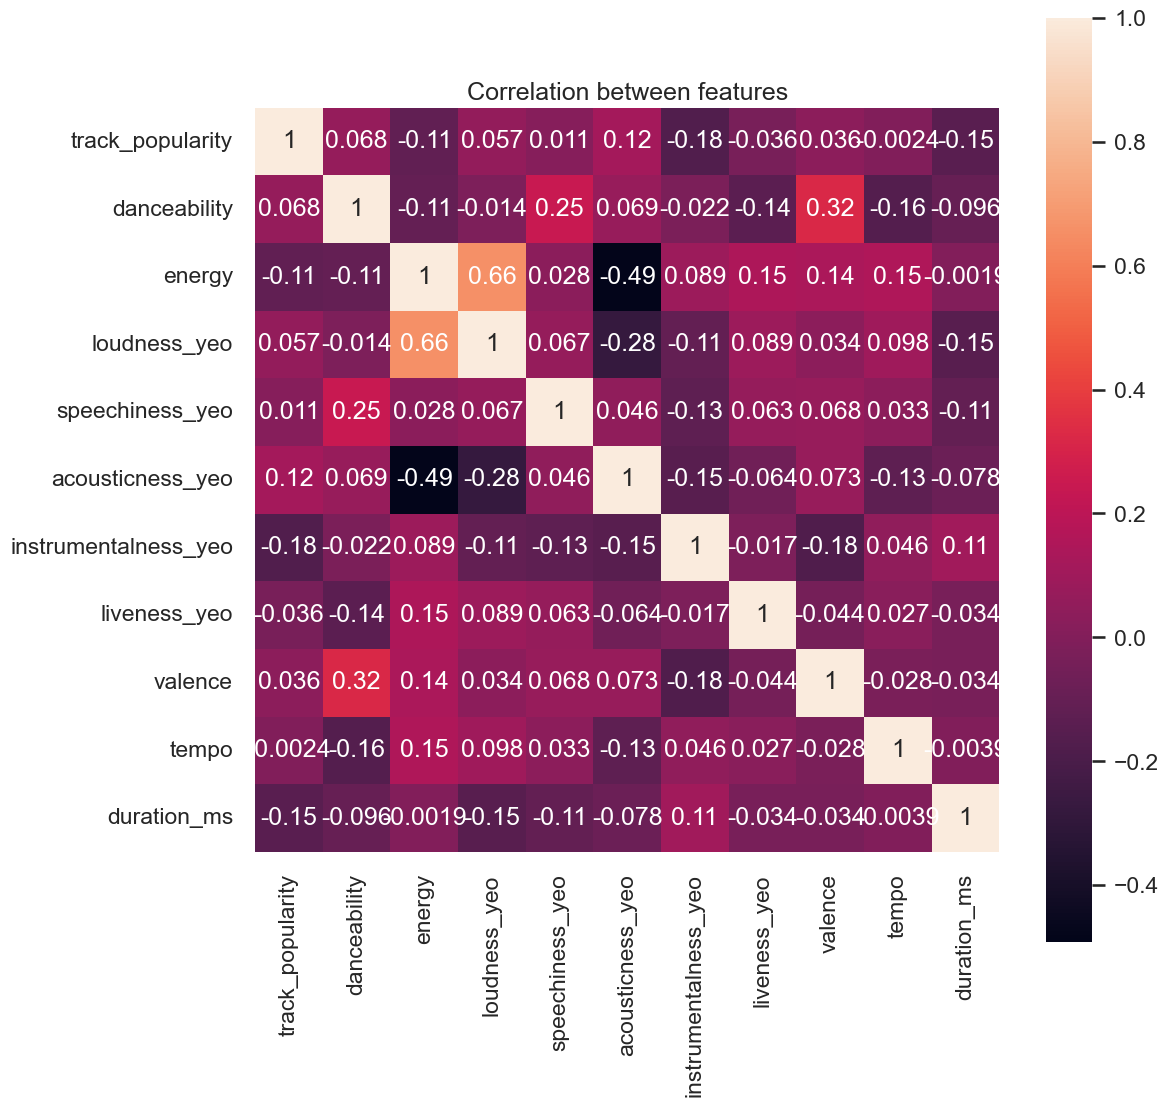

Les corrélations les plus fortes sont :
     Variable 1    Variable 2  Corrélation
1        energy      loudness        0.677
2        energy  acousticness       -0.540
3      loudness  acousticness       -0.362
0  danceability       valence        0.331


In [16]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, square=True, cmap='rocket')
plt.title('Correlation between features')
plt.show()


# seuil
alpha = 0.30

# variables numériques uniquement
num_data = data_complete.select_dtypes(include=np.number)

# matrice de corrélation
corr_matrix = num_data.corr()

# récupération des couples sans doublons
results = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr = corr_matrix.iloc[i, j]

        if abs(corr) > alpha:
            results.append([var1, var2, round(corr, 3)])

# dataframe trié
corr_df = pd.DataFrame(results, columns=["Variable 1", "Variable 2", "Corrélation"])
corr_df = corr_df.reindex(corr_df["Corrélation"].abs().sort_values(ascending=False).index)
print("Les corrélations les plus fortes sont :")
print(corr_df)



Seules quatre corrélations sont réellement marquées (\(|corr| > 0.3\)). Le reste est faible (\(< 0.2\)).

- `energy` et `loudness` sont fortement corrélées (\(corr=0.677\)) : les morceaux les plus énergiques sont généralement les plus forts en volume.

- `energy` et `acousticness` sont négativement corrélées (\(corr=-0.540\)) : intuitivement les morceaux acoustiques semblent être moins énergiques.

- `loudness` et `acousticness` sont aussi négativement corrélées (\(corr=-0.362\)) : les morceaux acoustiques ont tendance à être moins forts. L'énergie étant corrélée positivement à la loudness et négativement à l'acousticness, on retrouve logiquement une corrélation négative entre la puissance sonore et l'acoustique des morceaux.

- `danceability` et `valence` sont positivement corrélées (\(corr=0.331\)) : les morceaux dansants sont souvent plus joyeux ou positifs.

Les autres corrélations sont faibles. On peut seulement noter que la popularité est légèrement plus faible pour les morceaux instrumentaux ou plus longs. Les variables liées à l’intensité sonore et au caractère acoustique sont fortement liées entre elles. En revanche, la popularité dépend peu d’une variable isolée.

#### b) Analyse de la popularité par genre et sous-genre

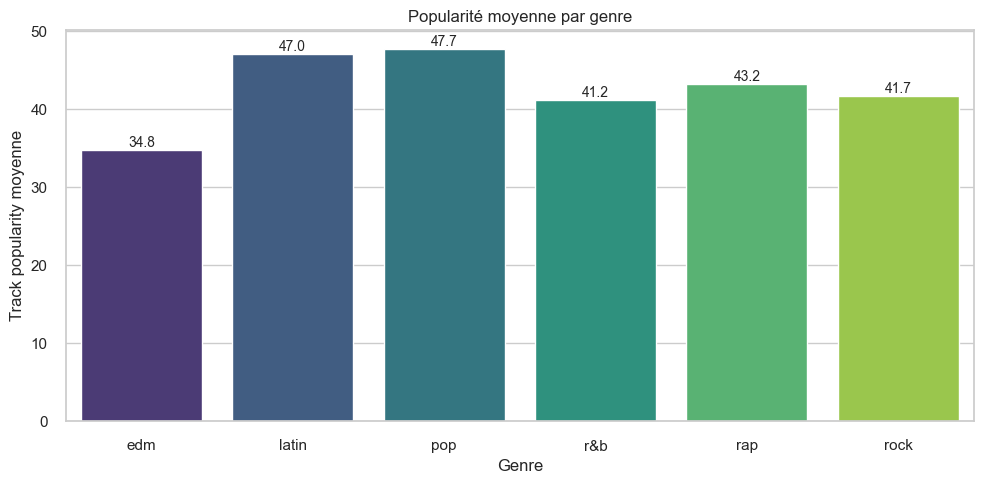

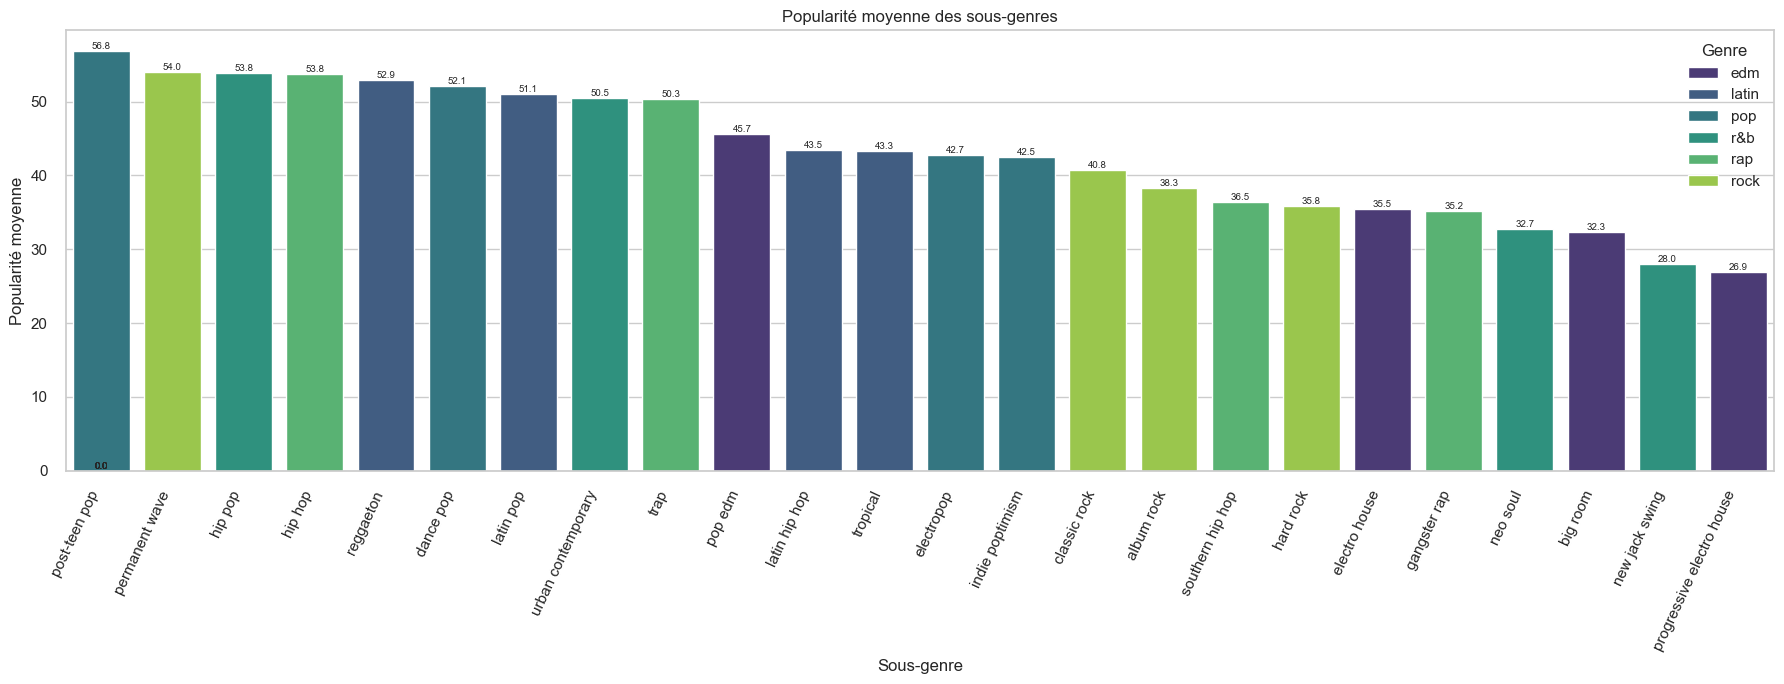

In [17]:
sns.set_theme(style="whitegrid")

# =========================
# Popularité moyenne / genre
# =========================
pop_genre = (
    data_complete
    .groupby("playlist_genre", as_index=False)["track_popularity"]
    .mean()
    .sort_values("track_popularity", ascending=False)
)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=pop_genre,
    x="playlist_genre",
    y="track_popularity",
    hue="playlist_genre",
    dodge=False,
    palette="viridis",
    legend=False
)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.title("Popularité moyenne par genre")
plt.xlabel("Genre")
plt.ylabel("Track popularity moyenne")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# popularité moyenne par sous-genre
pop_subgenre = (
    data_complete
    .groupby(["playlist_genre", "playlist_subgenre"], as_index=False)["track_popularity"]
    .mean()
    .sort_values("track_popularity", ascending=False)
)

plt.figure(figsize=(18,7))

ax = sns.barplot(
    data=pop_subgenre,
    x="playlist_subgenre",
    y="track_popularity",
    order=pop_subgenre["playlist_subgenre"],
    hue="playlist_genre",
    dodge=False,
    palette="viridis"
)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h:.1f}",
        (p.get_x() + p.get_width()/2, h),
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.title("Popularité moyenne des sous-genres")
plt.xlabel("Sous-genre")
plt.ylabel("Popularité moyenne")
plt.xticks(rotation=65, ha="right")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

Les genres les plus populaires en moyenne sont la **Pop** (47.7) et le **Latin** (47.0). À l’inverse, l’**EDM** est le genre le moins populaire (34.8), loin derrière les autres genres qui restent relativement proches, entre 41 et 43.

Concernant les sous-genres, les plus populaires sont **post-teen pop** (Pop), **permanent wave** (Rock), **hip pop** (R&B) et **hip hop** (Rap), tous au-dessus de 53. Les moins populaires sont **progressive electro house** (EDM), **new jack swing** (R&B) et **big room** (EDM). On observe donc une cohérence globale : plusieurs sous-genres les mieux classés appartiennent aux genres les plus populaires, tandis que l’EDM, déjà dernier au niveau global, contient aussi plusieurs sous-genres parmi les moins populaires.

L'analyse de la popularité moyenne selon le `mode` et la `key` a montré que la popularité ne change pas significativement en fonction des valeurs de ces derniers. Ainsi ces variables ne semblent pas impacter la variable `track_popularity` et donc le choix du mode ou de la tonalité principale de son morceau ne semble pas impacter la popularité du morceau. 

---

Remarque : Les sous-genres forment une classification exclusive : chaque sous-genre est rattaché à un seul genre principal, sans chevauchement entre catégories.


## II. Analyse des tendences (TEMPS)

## III. Analyse des genres

### c) Analyse des sous-genres

In [18]:

new_quant_cols = ['danceability', 'energy', 'loudness_yeo', 'speechiness_yeo',
       'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'valence', 'tempo',
       'duration_ms']

new_quant_cols_all = ['danceability', 'energy', 'loudness_yeo', 'speechiness_yeo',
       'acousticness_yeo', 'instrumentalness_yeo', 'liveness_yeo', 'valence', 'tempo',
       'duration_ms','track_popularity']

# Variables quantitatives à moyenner
vars_mean = [
    "track_popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms"
]

# Agrégation par genre + sous-genre
subgenre_stats = (
    data_complete
    .groupby(["playlist_genre", "playlist_subgenre"])[vars_mean]
    .mean()
    .reset_index()
)

# Tri : genre puis popularité décroissante
subgenre_stats = subgenre_stats.sort_values(
    ["playlist_genre", "track_popularity"],
    ascending=[True, False]
)

# Affichage propre groupé par genre
for genre in subgenre_stats["playlist_genre"].unique():
    print(f"Genre : {genre}")
    display(
        subgenre_stats[subgenre_stats["playlist_genre"] == genre]
        .round(2)
        .reset_index(drop=True)
    )

Genre : edm


,playlist_genre,playlist_subgenre,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,edm,pop edm,45.69,0.65,0.74,-5.45,0.09,0.14,0.05,0.20,0.46,123.17,205710.92
1,edm,electro house,35.51,0.70,0.80,-5.84,0.09,0.09,0.32,0.19,0.43,124.98,216682.58
2,edm,big room,32.28,0.62,0.86,-4.70,0.09,0.04,0.24,0.25,0.32,128.87,203852.39
3,edm,progressive electro house,26.87,0.65,0.82,-5.54,0.08,0.05,0.26,0.21,0.37,126.54,254006.40


Genre : latin


,playlist_genre,playlist_subgenre,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,latin,reggaeton,52.93,0.76,0.75,-5.34,0.12,0.20,0.00,0.18,0.68,119.28,218079.31
1,latin,latin pop,51.10,0.69,0.69,-6.19,0.09,0.25,0.01,0.19,0.61,119.64,216682.39
2,latin,latin hip hop,43.48,0.72,0.73,-6.19,0.12,0.15,0.04,0.18,0.62,119.14,225623.85
3,latin,tropical,43.33,0.69,0.68,-7.11,0.07,0.26,0.10,0.18,0.53,116.51,204810.37


Genre : pop


...

,playlist_genre,playlist_subgenre,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,r&b,hip pop,53.84,0.68,0.62,-6.87,0.12,0.26,0.03,0.17,0.51,116.03,211897.17
1,r&b,urban contemporary,50.52,0.65,0.57,-7.63,0.13,0.30,0.02,0.17,0.47,118.26,228450.26
2,r&b,neo soul,32.69,0.65,0.54,-8.33,0.12,0.31,0.04,0.18,0.51,110.10,239197.75
3,r&b,new jack swing,28.03,0.72,0.65,-8.59,0.09,0.14,0.02,0.18,0.66,113.17,275128.55


Genre : rap


,playlist_genre,playlist_subgenre,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,rap,hip hop,53.77,0.72,0.57,-8.24,0.19,0.31,0.22,0.17,0.51,118.26,181696.04
1,rap,trap,50.31,0.72,0.66,-6.53,0.14,0.22,0.07,0.17,0.44,130.03,200910.66
2,rap,southern hip hop,36.47,0.71,0.68,-6.91,0.20,0.12,0.02,0.21,0.55,119.13,247007.69
3,rap,gangster rap,35.19,0.72,0.69,-6.56,0.25,0.15,0.02,0.21,0.51,116.29,217600.00


Genre : rock


,playlist_genre,playlist_subgenre,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,rock,permanent wave,54.00,0.53,0.71,-7.58,0.05,0.14,0.09,0.19,0.55,124.88,244210.83
1,rock,classic rock,40.81,0.55,0.70,-8.29,0.05,0.19,0.05,0.19,0.61,123.61,256666.65
2,rock,album rock,38.32,0.53,0.66,-8.89,0.05,0.21,0.08,0.22,0.52,122.46,255363.04
3,rock,hard rock,35.84,0.49,0.83,-6.05,0.07,0.06,0.05,0.21,0.48,128.08,239897.42


### Etude des moyennes par sous-genre

L’étude des moyennes par sous-genre met en évidence une forte hétérogénéité de `track_popularity` à l’intérieur de chaque genre. Autrement dit, appartenir à un genre globalement populaire ne garantit pas qu’un sous-genre le soit aussi. À l’inverse, certains sous-genres ressortent nettement au sein de leur genre, ce qui montre que la popularité ne s’explique pas seulement par le genre principal mais aussi par une structure plus fine liée au sous-genre.

On observe notamment que certains sous-genres sont très bien classés en popularité moyenne et leur nom est connu du grand public, nous penson notamment au `hip hop` en Rap, `hip pop` en R\&B et au `reggaeton` en Latin. À l’inverse, chaque genre contient aussi au moins un sous-genre nettement moins populaire, comme `progressive electro house` en EDM, `new jack swing` en R\&B ou `hard rock` en Rock.

Cette hétérogénéité apparaît clairement dans les écarts de popularité observés à l’intérieur des genres. Par exemple, en Pop, `post-teen pop` atteint 56.83 contre 42.48 pour `indie poptimism`. L’effet sous-genre est donc important et parfois plus discriminant que l’effet genre lui-même.

En revanche, à la lecture directe des moyennes des autres variables (`danceability`, `energy`, `valence`, `tempo`, `acousticness`, etc.), aucun lien simple et universel avec la popularité ne ressort de manière évidente. Les sous-genres les plus populaires ne sont pas systématiquement les plus énergiques, les plus dansants, les plus positifs ou les moins acoustiques. On observe bien quelques tendances locales, par exemple des sous-genres populaires souvent peu instrumentaux et relativement élevé en tempo et en énergie, mais rien de suffisamment net pour conclure à ce stade.

Il est donc pertinent de poursuivre l’analyse avec une étude plus ciblée des corrélations entre `track_popularity` et les autres variables.

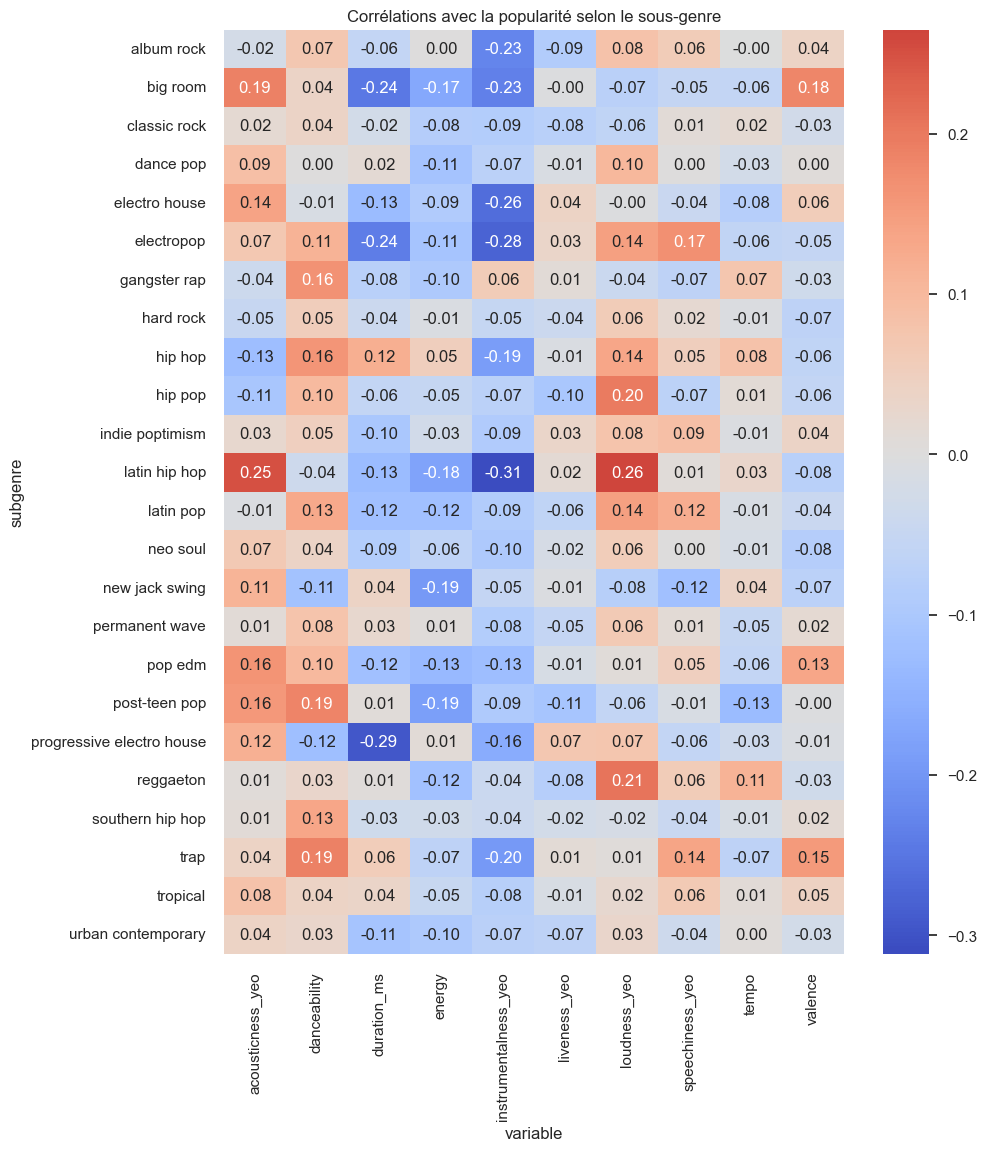

In [19]:
# Variables à tester
vars_corr = [
    "danceability",
    "energy",
    "loudness_yeo",
    "speechiness_yeo",
    "acousticness_yeo",
    "instrumentalness_yeo",
    "liveness_yeo",
    "valence",
    "tempo",
    "duration_ms"
]

rows = []

for sub, df_sub in data.groupby("playlist_subgenre"):
    
    # éviter corrélations absurdes si trop peu de lignes
    if len(df_sub) < 5:
        continue
        
    for var in vars_corr:
        r = df_sub["track_popularity"].corr(df_sub[var])
        
        rows.append({
            "subgenre": sub,
            "variable": var,
            "correlation": r
        })

corr_subgenre = pd.DataFrame(rows)

pivot = corr_subgenre.pivot(
    index="subgenre",
    columns="variable",
    values="correlation"
)

plt.figure(figsize=(10,12))
sns.heatmap(
    pivot,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Corrélations avec la popularité selon le sous-genre")
plt.show()

### Corrélations entre variables musicales et popularité selon le sous-genre

Cette heatmap confirme que le lien entre variables musicales et popularité reste globalement faible : les corrélations observées demeurent modérées, ce qui indique qu’aucune variable prise isolément n’explique clairement le succès d’un morceau.

Quelques tendances se dégagent néanmoins. La `danceability` est souvent positivement associée à la popularité. À l’inverse, `instrumentalness` est fréquemment corrélée négativement, ce qui montre que les morceaux très instrumentaux sont souvent moins populaires auprès du grand public.

Certaines relations varient toutefois selon le sous-genre. Par exemple, l’effet de `acousticness` n’est pas le même selon les univers musicaux. Cela montre que les attentes des auditeurs diffèrent selon les contextes d’écoute.

La popularité apparaît donc comme un phénomène multifactoriel, fortement dépendant du sous-genre étudié, plutôt que régi par une règle universelle.

### Réalisation d'une ACP sur les sous-genres


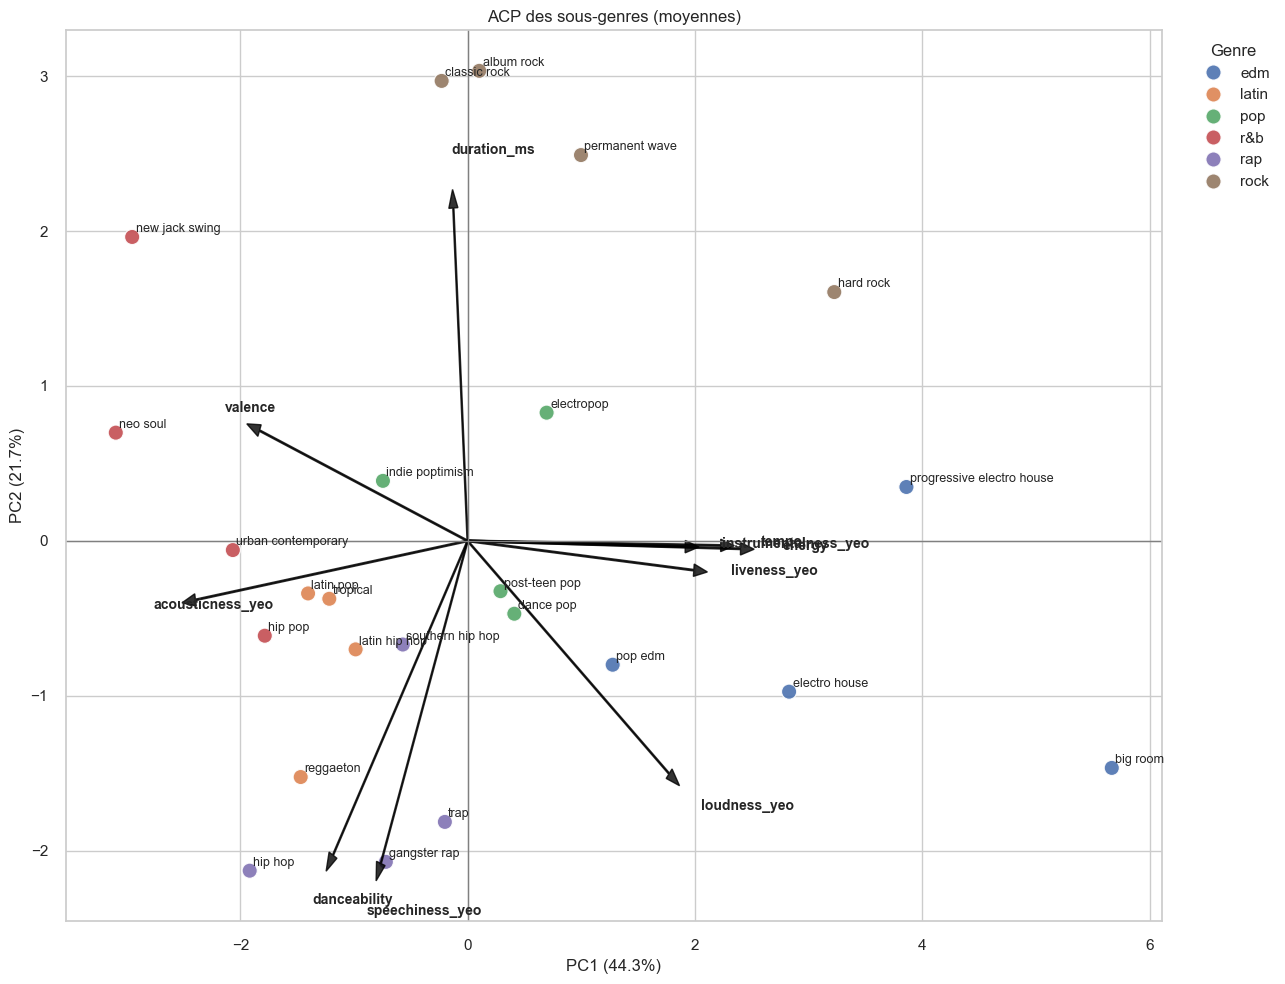

In [20]:
sns.set_theme(style="whitegrid")


sub_df = (
    data
    .groupby(["playlist_genre", "playlist_subgenre"], as_index=False)[new_quant_cols]
    .mean()
)

# ==================================================
# 2. ACP sur les sous-genres moyens
# ==================================================
X = sub_df[new_quant_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
coords = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
pc1 = var_exp[0] * 100
pc2 = var_exp[1] * 100

sub_df["PC1"] = coords[:,0]
sub_df["PC2"] = coords[:,1]

# ==================================================
# 3. Loadings (corrélations variables / axes)
# ==================================================
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

load_df = pd.DataFrame(
    loadings[:, :2],
    index=new_quant_cols,
    columns=["PC1", "PC2"]
)

# ==================================================
# 4. Biplot
# ==================================================
plt.figure(figsize=(13,10))

# points = sous-genres
sns.scatterplot(
    data=sub_df,
    x="PC1",
    y="PC2",
    hue="playlist_genre",
    s=120,
    alpha=0.9
)

# noms des sous-genres
for _, row in sub_df.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"] + 0.03,
        row["playlist_subgenre"],
        fontsize=9
    )

# flèches variables
scale = 2.8   # taille des flèches

for var in load_df.index:
    x = load_df.loc[var, "PC1"] * scale
    y = load_df.loc[var, "PC2"] * scale

    plt.arrow(
        0, 0, x, y,
        color="black",
        alpha=0.8,
        width=0.01,
        head_width=0.08,
        length_includes_head=True
    )

    plt.text(
        x*1.10,
        y*1.10,
        var,
        fontsize=10,
        fontweight="bold"
    )

plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)

plt.xlabel(f"PC1 ({pc1:.1f}%)")
plt.ylabel(f"PC2 ({pc2:.1f}%)")
plt.title("ACP des sous-genres (moyennes)")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Une ACP a été réalisée sur les sous-genres à partir des moyennes des variables musicales en excluant `track_popularity`. Les deux premières composantes expliquent une part importante de l’information : **44.3 % pour la PC1** et **21.7 % pour la PC2**, soit environ **66 %** de la variance totale. 

La composante **PC1** est positivement corrélée à `loudness_yeo`, `energy`, `tempo`, `instrumentalness_yeo` et `liveness_yeo`, et négativement corrélée à `acousticness_yeo` et `valence`. Elle permet de distinguer principalement les sous-genres **EDM**, situés sur les valeurs positives, des sous-genres **R&B**, situés sur les valeurs négatives, tandis que la **Pop** et le **Rock** ne se distinguent pas sur cet axe. Elle semble représenter un axe opposant des productions puissantes (en énergie/bruit), rapides et électroniques à des morceaux plus acoustiques, doux et positifs. La PC1 semble représenter l'intensité de la musique mélant l'énergie et la présence d'instruments et d'un public. 

La composante **PC2** est très fortement dominée par `duration_ms`, et dans une moindre mesure par `valence`. Elle s’oppose surtout à `danceability` et `speechiness`. Cet axe sépare donc des morceaux **plus longs, plus construits ou plus progressifs** de morceaux **courts, rythmés et dançant**. La composante **PC2** semble représenter la **structure du morceau**, en distinguant des titres longs et plus développés de morceaux plus courts, directs et dançant.

La position des sous-genres est cohérente avec cette lecture. Par exemple, `album rock`, `classic rock` et `permanent wave` sont très hauts sur la PC2, ce qui correspond à des morceaux plus longs. À l’inverse, `hip hop`, `trap` ou `gangster rap` sont bas sur la PC2, donc plus dançant et chantant. De même, `big room`, `electro house` ou `progressive electro house` sont très à droite sur la PC1, ce qui reflète des productions énergétiques et puissantes, alors que `neo soul` ou `latin pop` sont plus à gauche, avec des profils plus doux ou mélodiques.

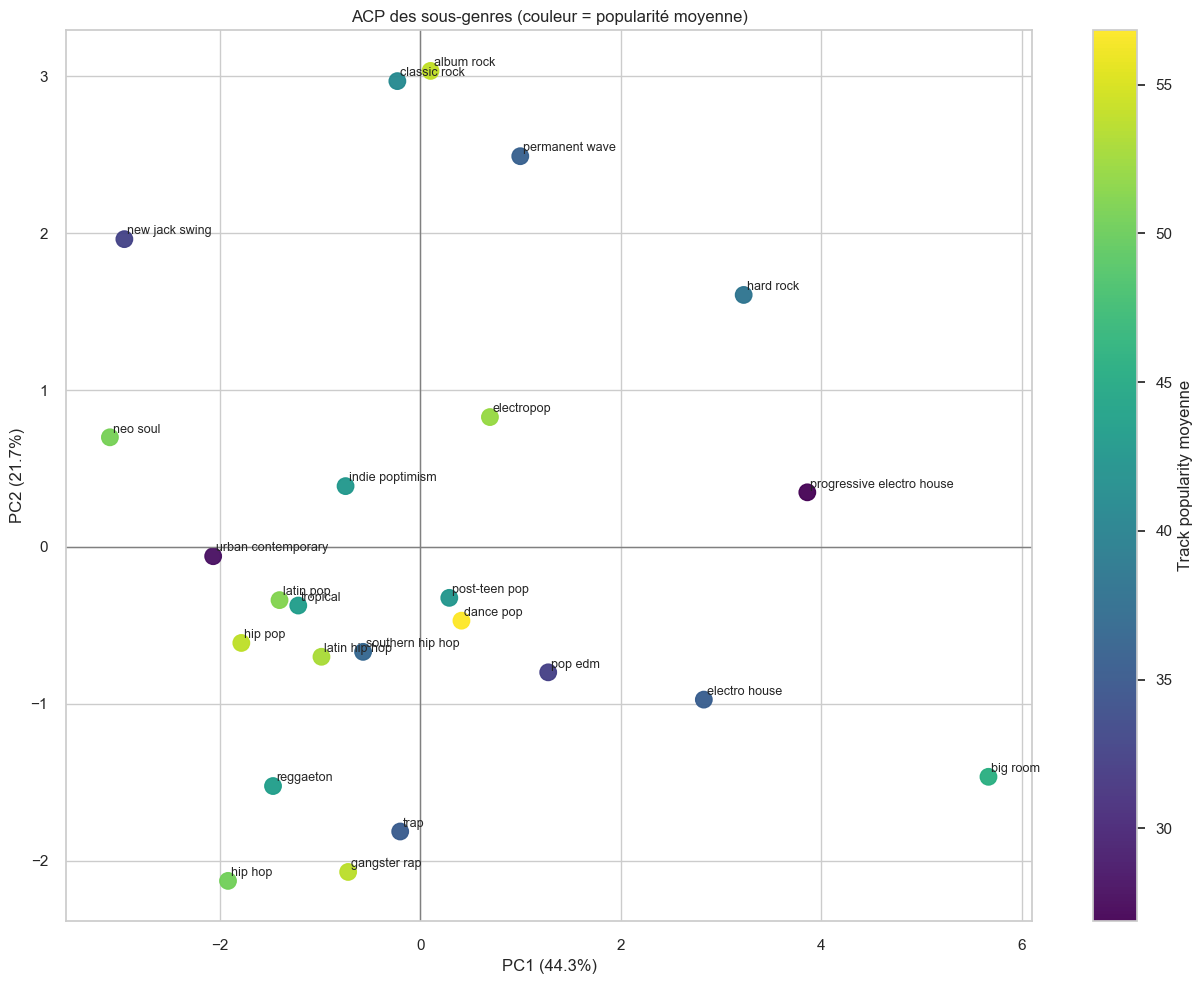

In [21]:
# ==================================================
# 2e graphique : mêmes sous-genres, couleur = popularité
# ==================================================

plt.figure(figsize=(13,10))

sc = plt.scatter(
    sub_df["PC1"],
    sub_df["PC2"],
    c=subgenre_stats["track_popularity"],
    cmap="viridis",
    s=140,
    alpha=0.95
)

# labels sous-genres
for _, row in sub_df.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"] + 0.03,
        row["playlist_subgenre"],
        fontsize=9
    )

# colorbar continue
cbar = plt.colorbar(sc)
cbar.set_label("Track popularity moyenne")

plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)

plt.xlabel(f"PC1 ({pc1:.1f}%)")
plt.ylabel(f"PC2 ({pc2:.1f}%)")
plt.title("ACP des sous-genres (couleur = popularité moyenne)")
plt.tight_layout()
plt.show()

Le graphique coloré par la popularité moyenne ne fait pas apparaître de séparation parfaitement nette dans le plan des deux premières composantes principales. Les sous-genres les plus populaires sont globalement situés dans certaines zones du plan, mais plusieurs exceptions subsistent, ce qui empêche de conclure visuellement à une relation simple entre la position sur le plan et la popularité.

On observe néanmoins une tendance possible : les sous-genres combinant des valeurs faibles sur les deux composantes semblent avoir une popularité relativement haute. Afin de tester cette intuition de manière quantitative, on peut étudier la corrélation entre la popularité moyenne et un score synthétique de type `-(PC1 + PC2)`, qui combine simultanément les deux composantes principales.

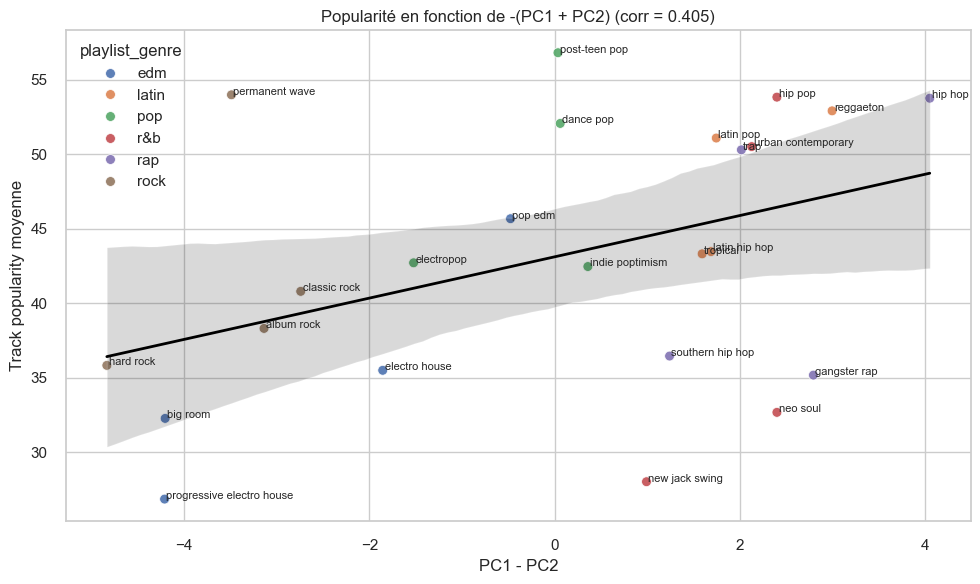

In [22]:
# ==================================================
# Graphe : (PC1 - PC2) en abscisse, popularité en ordonnée
# ==================================================

sub_df["score"] = -(sub_df["PC1"] + sub_df["PC2"])
sub_df["track_popularity"] = subgenre_stats["track_popularity"]
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sub_df,
    x="score",
    y="track_popularity",
    hue="playlist_genre",
    s=50,
    alpha=0.9
)

# labels
for _, row in sub_df.iterrows():
    plt.text(
        row["score"] + 0.02,
        row["track_popularity"] + 0.01,
        row["playlist_subgenre"],
        fontsize=8
    )

# droite de tendance
sns.regplot(
    data=sub_df,
    x="score",
    y="track_popularity",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

corr_val = sub_df["score"].corr(sub_df["track_popularity"])

plt.xlabel("PC1 - PC2")
plt.ylabel("Track popularity moyenne")
plt.title(f"Popularité en fonction de -(PC1 + PC2) (corr = {corr_val:.3f})")
plt.tight_layout()
plt.show()

### Analyse de la popularité en fonction du score -(PC1 + PC2)

Ce graphique met en évidence une corrélation positive modérée (\(r = 0.405\)) entre le score `-(PC1 + PC2)` et la popularité moyenne des sous-genres. Une tendance croissante apparaît globalement : certains sous-genres associés à des valeurs plus basses de PC1 et PC2 présentent en moyenne une popularité plus élevée.

Il faut toutefois interpréter ce résultat avec prudence. L’analyse est réalisée sur des **moyennes de sous-genres** et non sur les morceaux individuels. Chaque point résume un ensemble de titres parfois très hétérogènes. Une relation visible sur les moyennes ne reflète donc pas nécessairement le comportement réel des morceaux pris individuellement.

### Conclusion sur cette étude des sous-genres

L’analyse fine des sous-genres montre que la popularité reste difficile à expliquer par quelques variables musicales seulement. Malgré plusieurs approches (moyennes, corrélations locales, ACP), aucun facteur unique ne ressort de manière flagrante. La popularité apparaît comme un phénomène **multifactoriel**, influencé par de nombreux éléments parfois absents de la base (marketing, contexte culturel, tendance du moment, viralité).

L’ACP met néanmoins en évidence une structure musicale cohérente : les sous-genres se regroupent relativement bien par grands genres, ce qui suggère l’existence de caractéristiques communes au sein d’un même univers musical. Les genres ont donc un réel sens en termes de proximité sur les variables étudiées.

En revanche, cette structure musicale ne se traduit pas directement en règles simples de popularité. Les attentes diffèrent fortement selon les styles : une caractéristique peut être favorable dans un genre et neutre ou défavorable dans un autre. Par exemple, l’effet de `acousticness` varie selon les sous-genres étudiés.

Cette étude montre ainsi que les comportements **intra-genre** sont complexes et que les généralisations restent compliquer à établir sur des jeux de données réels. Cette difficulté de prédiction peut s'expliquer à la fois par le manque d'informations(contexte) et la compexité du problème.

## IV. Analyse des facteurs de succès

## V. Création de playlists

### c) Méthodes pour créer des playlists

Plusieurs méthodes de clustering ont été mobilisées afin d’explorer différentes structures possibles et de comparer les regroupements obtenus selon la représentation choisie des morceaux.

Une première approche repose sur une Analyse en Composantes Principales (ACP) suivie d’un algorithme K-means. L’ACP permet de réduire la dimension des variables quantitatives en conservant l’essentiel de la variance, puis K-means forme des groupes compacts dans cet espace simplifié.

Une seconde approche utilise une Analyse Factorielle Multiple (MFA), dans laquelle les variables sont organisées en groupes thématiques (acoustique, dynamique, rythme, durée, etc.). Les coordonnées factorielles obtenues servent ensuite de base à une classification hiérarchique agglomerative, permettant d’observer les rapprochements progressifs entre morceaux et de faire apparaître différents niveaux de segmentation.

La troisième méthode combine également la MFA avec un modèle de mélange gaussien (Gaussian Mixture Model). Cette approche probabiliste autorise des frontières plus souples entre clusters et s’adapte mieux aux morceaux présentant des caractéristiques intermédiaires entre plusieurs styles. Pour aller plus loin, il serait alors possible de créer des playlists sans frontières strictes où chaque musique a une certaine probabilité d'être jouée en fonction de ses similiratiés avec les autres musiques de cette playlist.

Enfin, une dernière variante intègre explicitement les genres musicaux dans la MFA, via un encodage en variables indicatrices, avant d’appliquer K-means. Les clusters obtenus reposent alors à la fois sur les propriétés audio des morceaux et sur l’information de genre déclarée. Le but ici est de proposer des playlists qui regroupent des musiques du même genre avec une certaine part d'ouverture vers les autres genres.

### Playlists créées avec PCA et Kmeans

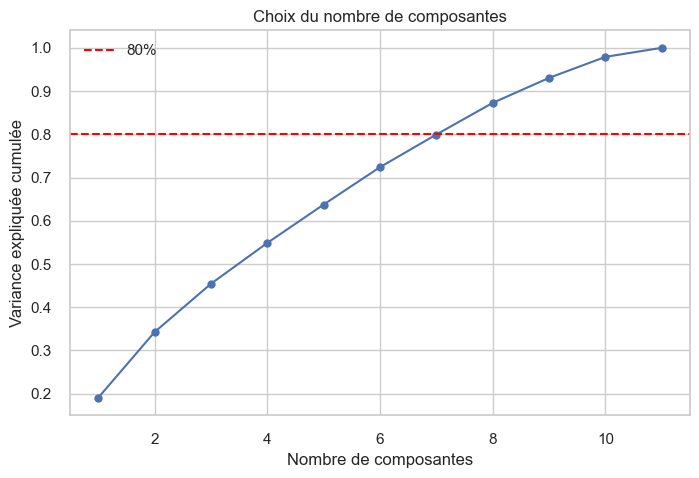

Nombre de composantes retenues : 8


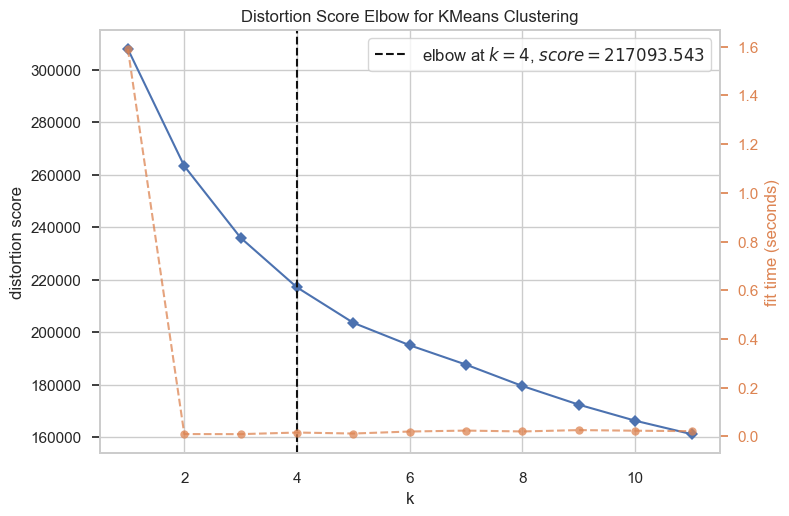

cluster
0    3219
1    3343
2    4716
3    3878
4    4838
5    2682
6    1312
7    2804
8    3752
9    1526
Name: count, dtype: int64


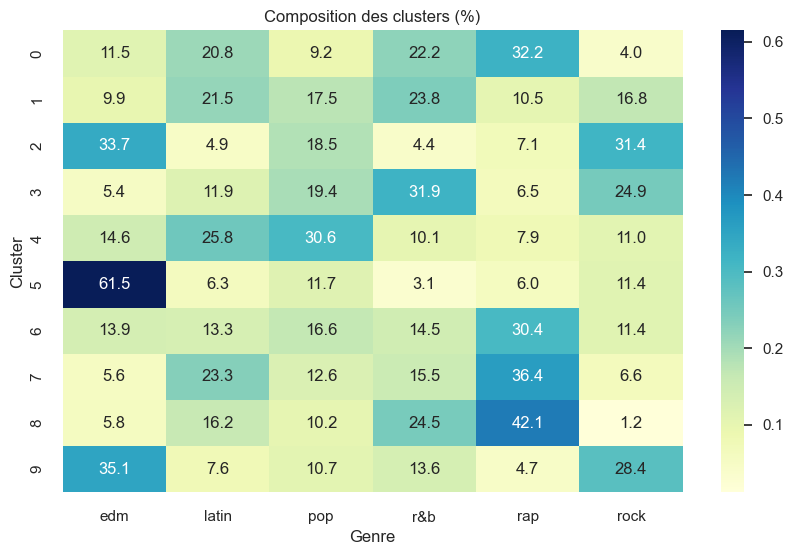

In [23]:
# ==================================================
# 1. Données quantitatives
# ==================================================
X = data[new_quant_cols_all].copy()
y = data["playlist_genre"].copy()

sns.set_theme(style="whitegrid")



# ==================================================
# 2. ACP
# ==================================================
pca = PCA()
X_pca_full = pca.fit_transform(X)

# Variance expliquée cumulée
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.80, color="red", linestyle="--", label="80%")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Choix du nombre de composantes")
plt.legend()
plt.show()

# Nombre minimal de composantes pour 80%
n_comp = np.argmax(cum_var >= 0.80) + 1
print(f"Nombre de composantes retenues : {n_comp}")

# Projection réduite
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X)

# ==================================================
# 3. Elbow Method
# ==================================================
kmeans = KMeans(
    init='k-means++',
    n_init='auto',
    max_iter=100,
    random_state=42
)

visualizer = KElbowVisualizer(
    kmeans,
    k=(1,12),
    force_model=True
)

visualizer.fit(X_pca)
visualizer.show()


# ===============================================
# 4. Choisir K manuellement après lecture elbow
# ===============================================
K = 10   # à ajuster selon ton graphe

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

data_cluster = data.copy()
data_cluster["cluster"] = clusters

print(data_cluster["cluster"].value_counts().sort_index())

# ==================================================
# 5. Matrice confusion : ligne = cluster
# ==================================================
conf_row = pd.crosstab(
    data_cluster["cluster"],
    data_cluster["playlist_genre"],
    normalize="index"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    conf_row,
    annot=(conf_row*100).round(1),
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Composition des clusters (%)")
plt.xlabel("Genre")
plt.ylabel("Cluster")
plt.show()


Nous appliquons ici une Analyse en Composantes Principales (ACP) suivie d’un clustering K-means. Le principe est de projeter les morceaux dans un espace latent plus compact, puis de former des groupes dans cet espace. Cette réduction de dimension permet de supprimer une partie du bruit et de concentrer l’analyse sur les structures principales des données.

Le choix du nombre de composantes est réalisé à partir de la variance expliquée cumulée. Le seuil de 80% est atteint avec **8 composantes principales**.

Le nombre de clusters est ensuite étudié par la méthode du coude. Le graphique suggère un coude autour de **4 groupes**. Toutefois, notre objectif n’est pas de retrouver un nombre “exact” de classes naturelles, mais de construire des playlists. Ainsi, ce nombre peut être interprété comme une borne minimale qui permet de capturer l'hétérogénéité du jeu de données. Nous fixons **K = 10** afin d’obtenir une segmentation plus fine. Le nombre de clusters pourra ensuite être ajusté selon la taille souhaitée des playlists. Les effectifs des clusters ne sont pas équilibrés, et sont compris entre **1 312** et **4 838** morceaux selon les groupes. Ainsi un problème de la méthode des k-means dans notre cas est que l'on ne contrôle pas la taille des playlists.

Les matrices de confusion montrent que les clusters restent globalement **hétérogènes en termes de genres**. La plupart des groupes contiennent plusieurs styles musicaux avec des proportions proches, sans genre dominant clairement identifié. Cela signifie que les morceaux sont bien regroupés selon leurs caractéristiques quantitatives, mais que ces variables ne suffisent pas à retrouver finement les frontières entre genres.

Le cas le plus visible concerne **l’EDM**, qui apparaît majoritaire dans le cluster 5. Pour les autres genres, la dispersion est importante : un même genre se retrouve réparti dans plusieurs clusters, et plusieurs genres cohabitent dans un même groupe.

En conclusion, cette première approche constitue un bon point de départ pour détecter des proximités audio globales, mais elle reste limitée pour la création de playlists ciblées par style. Les clusters sont cohérents statistiquement, mais pas assez discriminants musicalement en terme de genres. Nous chercherons donc à mieux capter les différences entre genres avec une Analyse Factorielle Multiple (MFA). De plus, nous utiliserons d'autres méthodes de clustering afin de pouvoir mieux gérer la taille des playlists.

### Playlists créées avec MFA et classification hiérarchique ascendante 

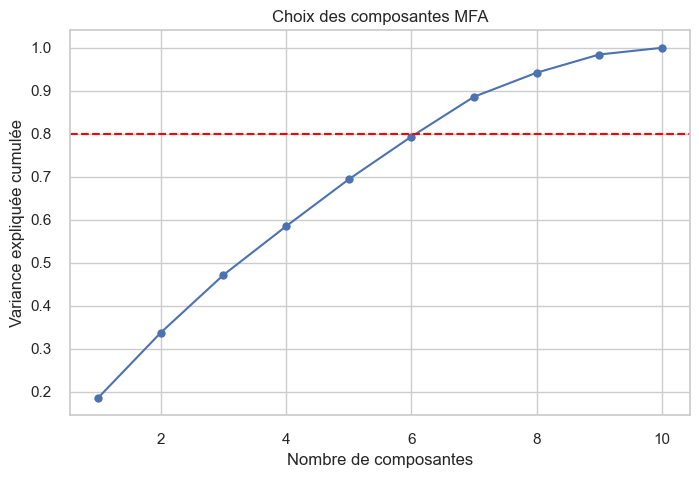

Nombre de composantes retenues (>80%) : 7


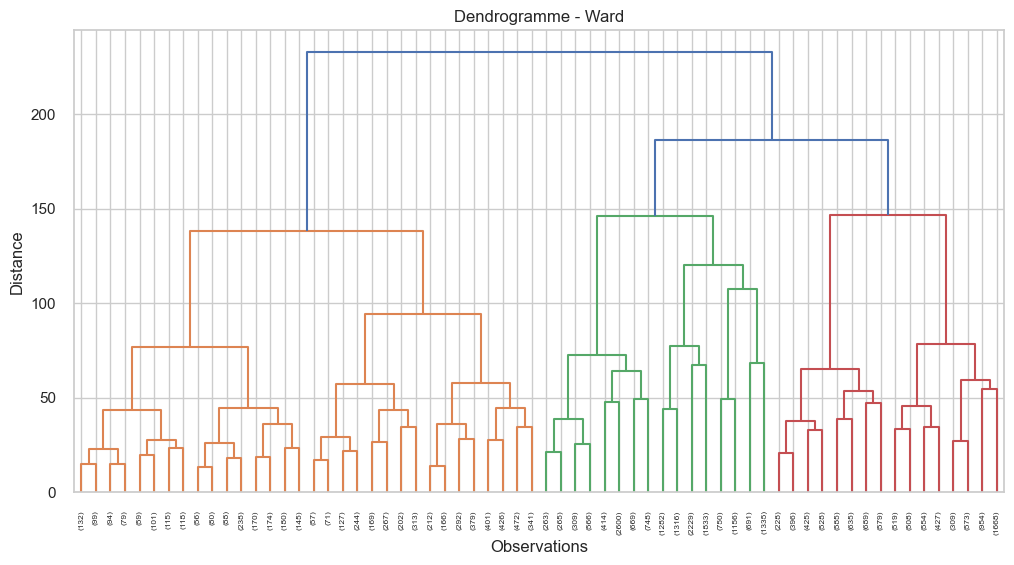

cluster
0    6660
1    5834
2    1928
3    4065
4    2026
5    3504
6    2689
7    1906
8    1450
9    2008
Name: count, dtype: int64


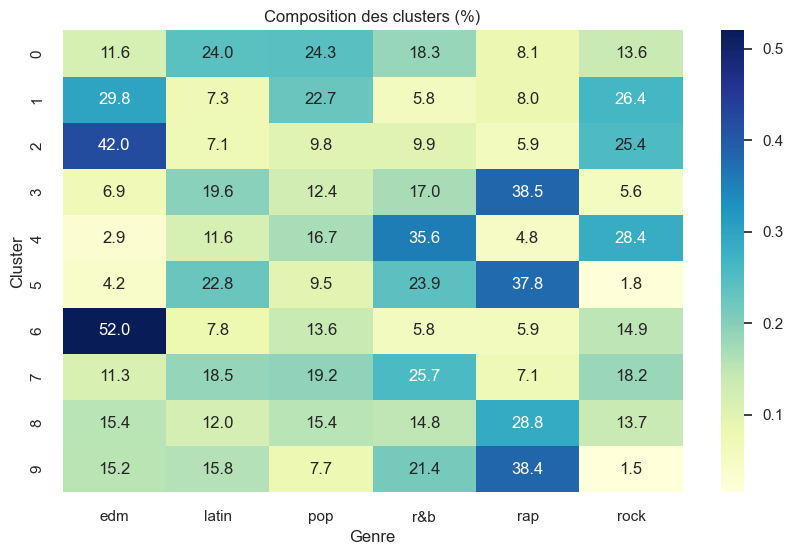

In [24]:
# ==================================================
# 1. Données + Groupes MFA
# ==================================================
groups = {
    'G1_Power': ['loudness_yeo', 'energy', 'acousticness_yeo'],
    'G2_Vibe': ['danceability', 'valence'],
    'G3_Pop': ['track_popularity'],
    'G4_Duration': ['duration_ms'],
    'G5_TempoLive': ['tempo'],
    'G6_InstrumSpeechiness': ['instrumentalness_yeo', 'speechiness_yeo']
}## ici on a enlevé liveness

quant_cols_mfa1 = [col for g in groups.values() for col in g]

# ==================================================
# 2. MFA
# ==================================================
mfa = prince.MFA(
    n_components=len(quant_cols_mfa1),
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mfa = mfa.fit(X, groups=groups)
X_mfa = mfa.transform(X)

# noms colonnes
X_mfa.columns = [f"PC{i+1}" for i in range(X_mfa.shape[1])]

# ==================================================
# 3. Nombre de composantes > 80%
# ==================================================
eig = np.array(mfa.eigenvalues_)
cum_var = np.cumsum(eig / eig.sum())

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.80, color="red", linestyle="--")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Choix des composantes MFA")
plt.show()

n_comp = np.argmax(cum_var >= 0.80) + 1
print(f"Nombre de composantes retenues (>80%) : {n_comp}")

df_mfa_clustering = X_mfa.iloc[:, :n_comp].copy()

# ==================================================
# 4. Dendrogramme Ward
# ==================================================
Z = linkage(df_mfa_clustering, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrogramme - Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

# ==================================================
# 5. Choix manuel K
# ==================================================
K = 10   # à adapter après lecture dendrogramme

model = AgglomerativeClustering(
    n_clusters=K,
    linkage="ward"
)

clusters = model.fit_predict(df_mfa_clustering)

df_result = data.copy()
df_result["cluster"] = clusters

print(df_result["cluster"].value_counts().sort_index())

# ==================================================
# 6. Heatmap cluster -> genres
# ==================================================
conf_row = pd.crosstab(
    df_result["cluster"],
    df_result["playlist_genre"],
    normalize="index"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    conf_row,
    annot=(conf_row*100).round(1),
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Composition des clusters (%)")
plt.xlabel("Genre")
plt.ylabel("Cluster")
plt.show()



Nous appliquons ensuite une MFA suivie d’une Classification Hiérarchique Ascendante (méthode de Ward) qui va chercher des clusters compacts. Les variables sont regroupées par familles afin d’équilibrer leur influence : puissance sonore (`loudness`, `energy`, `acousticness`), ambiance (`danceability`, `valence`), popularité, durée, tempo, puis dimension technique (`instrumentalness`, `speechiness`). Le seuil de 80% de variance expliquée est atteint avec **7 composantes**.

La coupe du dendrogramme en **10 clusters** produit des groupes de tailles très hétérogènes (de **1 450** à **6 660** morceaux) ce qui est peu intéressant dans le contexte de création de playlists.

Les résultats restent globalement mitigés. Quelques clusters présentent un genre légèrement dominant, notamment l’**EDM** ou le **Rap**, mais la majorité des groupes restent mixtes. 

Cette méthode reste insuffisante pour générer directement des playlists spécialisées.

### Playlists crées avec MFA et modèle de mélange Gaussian 

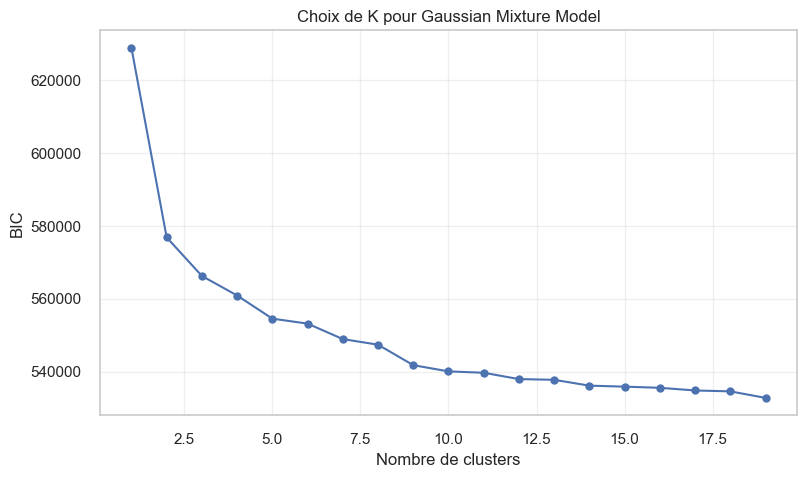

K choisi (minimum BIC) : 19
cluster
0      988
1     2047
2     1753
3     1731
4      511
5     3039
6     1641
7     2039
8     1850
9     1671
10    1044
11    1111
12    2423
13    1588
14    1536
15    2576
16    1810
17    1349
18    1363
Name: count, dtype: int64


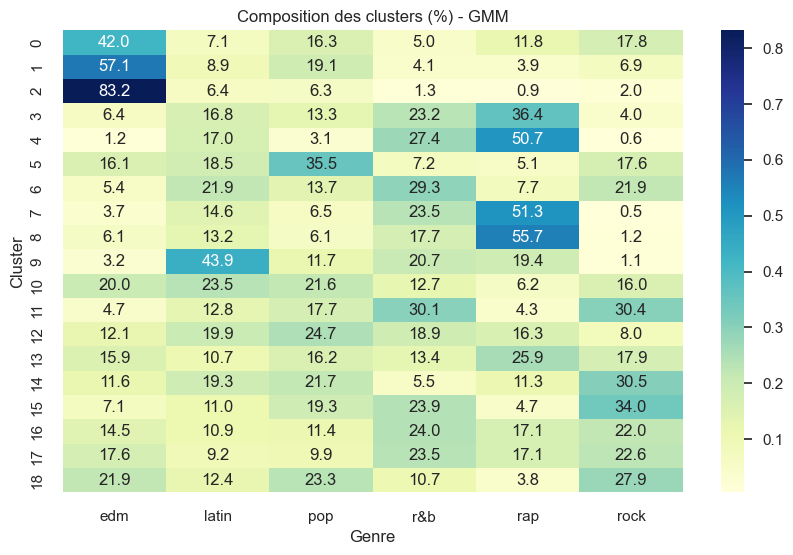

In [25]:
# ==================================================
# 4. Choix K avec BIC (à la place du dendrogramme / CAH)
# ==================================================
Ks = range(1, 20)
bic_scores = []

for k in Ks:
    gmm_test = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=3
    )
    
    gmm_test.fit(df_mfa_clustering)
    bic_scores.append(gmm_test.bic(df_mfa_clustering))

plt.figure(figsize=(9,5))
plt.plot(Ks, bic_scores, marker="o")
plt.xlabel("Nombre de clusters")
plt.ylabel("BIC")
plt.title("Choix de K pour Gaussian Mixture Model")
plt.grid(True, alpha=0.3)
plt.show()

K = Ks[np.argmin(bic_scores)]
print(f"K choisi (minimum BIC) : {K}")

# ==================================================
# 5. Clustering GMM
# ==================================================
gmm = GaussianMixture(
    n_components=K,
    covariance_type='full',
    random_state=42,
    n_init=5
)

clusters = gmm.fit_predict(df_mfa_clustering)

df_result = data.copy()
df_result["cluster"] = clusters

print(df_result["cluster"].value_counts().sort_index())

# ==================================================
# 6. Heatmap cluster -> genres
# ==================================================
conf_row = pd.crosstab(
    df_result["cluster"],
    df_result["playlist_genre"],
    normalize="index"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    conf_row,
    annot=(conf_row*100).round(1),
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Composition des clusters (%) - GMM")
plt.xlabel("Genre")
plt.ylabel("Cluster")
plt.show()

Nous appliquons un **Gaussian Mixture Model (GMM)** sur les composantes issues de la MFA. Le critère BIC ne présente pas de minimum net et décroît continuellement ; nous retenons donc la borne maximale testée, soit **19 clusters**.

Les résultats montrent des groupes parfois plus spécialisés que précédemment, avec par exemple des clusters fortement dominés par l’**EDM** (83.2%), le **Rap** (55%) ou le **Latin** (43.9%). La segmentation semble donc plus fine, même si certains genres comme le **Rock** ou le **R&B** restent moins clairement isolés.

L’intérêt principal du GMM est son aspect probabiliste : chaque morceau possède une **probabilité d’appartenance** à chaque cluster. Une même musique peut ainsi être associée à plusieurs playlists, ce qui rend la recommandation plus souple et plus réaliste qu’un clustering strict.

Voici, comme exemble, le vecteur de probabilité associée à la première musique du dataset. On observe que plusieurs clusters on une probabilité non négligeable de contenir cette musique :

In [ ]:
print(np.round(gmm.predict_proba(df_mfa_clustering)[0],2))

### Playlists créées en prenant en compte les genres

Dans une dernière approche, nous intégrons directement le **genre** dans la MFA, en plus des variables quantitatives. L’objectif est de construire des playlists avec un genre majoritaire, tout en laissant entrer des morceaux proches selon leurs caractéristiques audio.

Le critère étudié est la **pureté moyenne** des clusters : pour chaque cluster, on regarde la proportion du genre majoritaire, puis on fait la moyenne sur tous les clusters. Plus la pureté est élevée, plus les groupes sont spécialisés par genre.

Étape supplémentaire : Évolution de la pureté selon n_comp


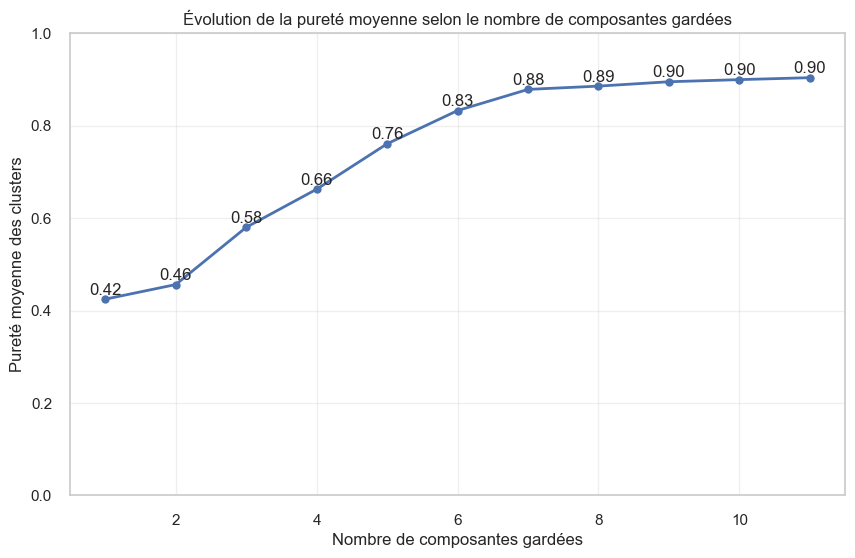

In [26]:
# ==================================================
# 1. Groupes MFA : 1 variable = 1 groupe
# ==================================================

groups_mfa3 = {
    'G1_acousticness': ['acousticness_yeo'],
    'G2_instrumentalness': ['instrumentalness_yeo'],
    'G3_speechiness': ['speechiness_yeo'],
    'G4_loudness': ['loudness_yeo'],
    'G5_energy': ['energy'],
    'G6_danceability': ['danceability'],
    'G7_tempo': ['tempo'],
    'G8_valence': ['valence'],
    'G9_duration': ['duration_ms'],
    'G10_popularity': ['track_popularity'],

    # le genre reste un groupe multi-colonnes
    'G11_genre': [
        'genre_edm', 'genre_latin', 'genre_pop',
        'genre_r&b', 'genre_rap', 'genre_rock'
    ]
}

# ==================================================
# 2. One-hot encoding du genre
# ==================================================

genre_dummies = pd.get_dummies(data["playlist_genre"], prefix="genre")

df_mfa3 = pd.concat(
    [data.reset_index(drop=True), genre_dummies.reset_index(drop=True)],
    axis=1
)

quant_col_mfa3 = [
    'acousticness_yeo',
    'instrumentalness_yeo',
    'speechiness_yeo',
    'loudness_yeo',
    'energy',
    'danceability',
    'tempo',
    'valence',
    'duration_ms',
    'track_popularity'
] + list(genre_dummies.columns)

# ==================================================
# 3. MFA
# ==================================================

mfa = prince.MFA(
    n_components=len(quant_col_mfa3),
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mfa = mfa.fit(df_mfa3[quant_col_mfa3], groups=groups_mfa3)

X_mfa = mfa.transform(df_mfa3[quant_col_mfa3])
X_mfa.columns = [f"PC{i+1}" for i in range(X_mfa.shape[1])]


# ==================================================
# Graphe : pureté moyenne des clusters selon n_comp
# ==================================================
print("Étape supplémentaire : Évolution de la pureté selon n_comp")



# plage testée
ncomp_range = range(1, min(12, X_mfa.shape[1] + 1))

purity_scores = []

for nc in ncomp_range:

    Z_test = X_mfa.iloc[:, :nc].copy()

    K_test=10

    # clustering final
    km_final = KMeans(
        n_clusters=K_test,
        random_state=42,
        n_init=10
    )

    labels = km_final.fit_predict(Z_test)

    tmp = data.copy()
    tmp["cluster"] = labels

    # tableau cluster -> genre (%)
    conf = pd.crosstab(
        tmp["cluster"],
        tmp["playlist_genre"],
        normalize="index"
    )

    # pureté = max de chaque ligne
    cluster_purity = conf.max(axis=1)

    # moyenne des puretés
    mean_purity = cluster_purity.mean()

    purity_scores.append(mean_purity)

# ==================================================
# Plot final
# ==================================================
plt.figure(figsize=(10,6))
plt.plot(
    list(ncomp_range),
    purity_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Nombre de composantes gardées")
plt.ylabel("Pureté moyenne des clusters")
plt.title("Évolution de la pureté moyenne selon le nombre de composantes gardées")
plt.grid(True, alpha=0.3)
plt.ylim(0,1)

for x, y in zip(ncomp_range, purity_scores):
    plt.text(x, y + 0.01, f"{y:.2f}", ha="center")

plt.show()


Le graphique montre que la pureté des playlists augmente avec le nombre de composantes conservées : elle passe d’environ **0.42** à **0.90**. Plus on garde d’information, plus les clusters reproduisent les genres existants.

Ce résultat doit cependant être nuancé : une pureté trop forte revient presque à recréer des playlists par genre uniquement, tandis qu’une pureté trop faible donne des groupes trop mélangés.

L’intérêt de cette méthode est donc de pouvoir ajuster le niveau de spécialisation des playlists :

- faible pureté : playlists variées et ouvertes ;  
- pureté intermédiaire : genre dominant avec diversité cohérente ;  
- forte pureté : playlists très ciblées sur un style.

On obtient ainsi un compromis entre fidélité aux goûts de l’utilisateur et découverte musicale. Ainsi après avoir tester plusieurs méthodes, celle-ci semble la plus adaptée à la création de playlists

Nombre de composantes retenues : 5
Répartition des clusters :
cluster
0    2215
1    2839
2    2413
3    4370
4    3489
5    3345
6    2747
7    4366
8    2775
9    3511
Name: count, dtype: int64


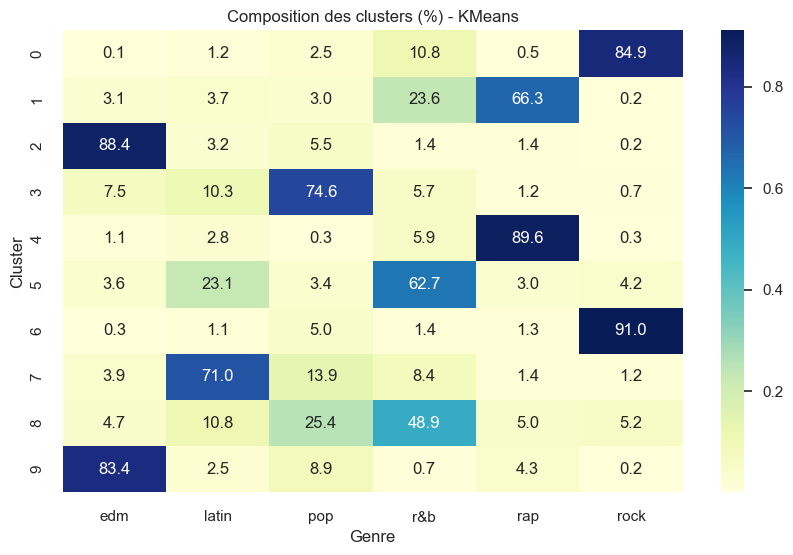

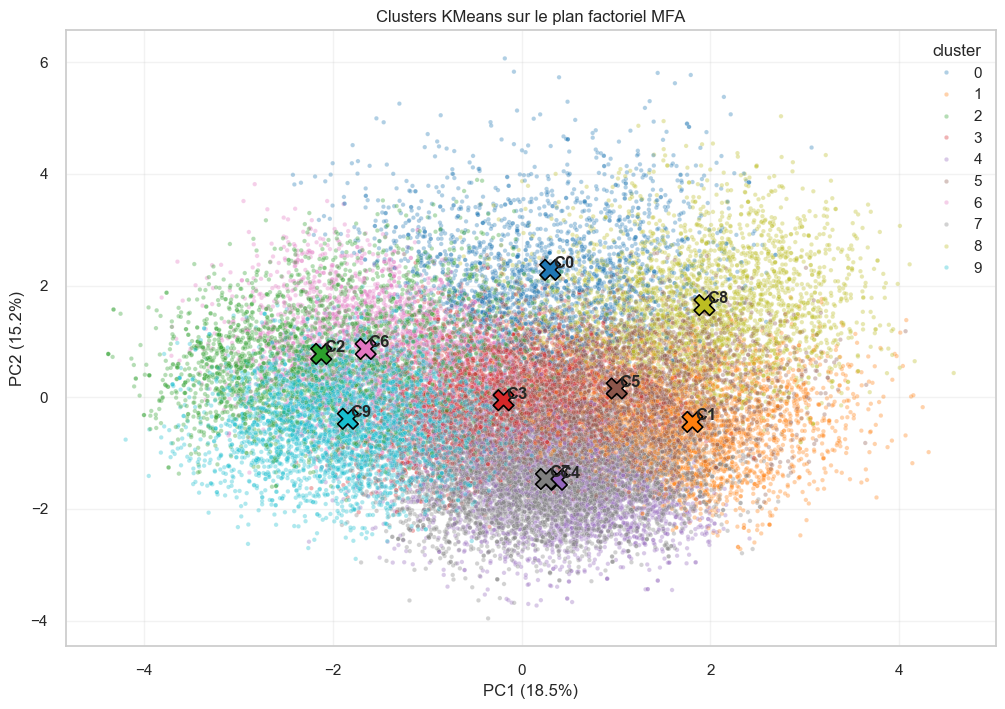

In [27]:
# ==================================================
# 4. Choix composantes
# ==================================================

n_comp=5
print(f"Nombre de composantes retenues : {n_comp}")

Z = X_mfa.iloc[:, :n_comp].copy()



# ==================================================
# 6. KMeans final

K=10
kmeans_final = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(Z)

data_cluster = data.copy()
data_cluster["cluster"] = clusters

print("Répartition des clusters :")
print(data_cluster["cluster"].value_counts().sort_index())

# ==================================================
# 7. Heatmap cluster -> genre
# ==================================================

conf_row = pd.crosstab(
    data_cluster["cluster"],
    data_cluster["playlist_genre"],
    normalize="index"
)

plt.figure(figsize=(10,6))
sns.heatmap(
    conf_row,
    annot=(conf_row*100).round(1),
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Composition des clusters (%) - KMeans")
plt.xlabel("Genre")
plt.ylabel("Cluster")
plt.show()


# ==================================================
# 9. Scatter clusters PC1-PC2
# ==================================================

plot_df = X_mfa.copy()
plot_df["cluster"] = clusters

centers = plot_df.groupby("cluster")[["PC1","PC2"]].mean().reset_index()

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.35,
    s=10
)

sns.scatterplot(
    data=centers,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=220,
    marker="X",
    edgecolor="black",
    linewidth=1.2,
    legend=False
)

for _, row in centers.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"] + 0.03,
        f"C{int(row['cluster'])}",
        weight="bold"
    )

var1 = eig[0]/eig.sum()*100
var2 = eig[1]/eig.sum()*100

plt.xlabel(f"PC1 ({var1:.1f}%)")
plt.ylabel(f"PC2 ({var2:.1f}%)")
plt.title("Clusters KMeans sur le plan factoriel MFA")
plt.grid(True, alpha=0.25)
plt.show()


Nous avons fixé le nombre de composantes à **5** et le nombre de playlists à **10**.

Les matrices de confusion montrent que chaque playlist possède désormais un **genre majoritaire marqué**, tout en conservant une part de morceaux issus de styles proches. On obtient ainsi des playlists lisibles pour l’utilisateur, mais moins rigides qu’un simple tri par genre.

Sur le plan factoriel, les classes se superposent partiellement, ce qui confirme une **mixité des genres** tout en conservant l’information de genre dans la construction des groupes.

## CONCLUSION